
<tr>
    <td><h1 style="text-align: left; font-size:300%;">
        ML2026 - Homework
    </h1></td>
    <div style="text-align: right">
    <b> Machine Learning 2026</b> <br>
    <td width="100px"> 
        
</tr>


### Packages

In [1]:
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [2]:
import numpy as np
np.random.seed(0)
import matplotlib
import matplotlib.pyplot as plt
from cycler import cycler

from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import train_test_split

In [3]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Task 1
_Perform preliminary analysis of the data. For instance, but not limited to, visualizing samples, identifying if features are correlated, determining which are most correlated with the target class, and inspecting the distribution of samples among classes. We want to recover the data for the Exit Rate variable. Train a regressor to predict this variable’s values given the remaining variables. Compare different regression algorithms for this task, and perform feature selection. Since this feature is also missing in the test set, use only the training data for this step and use robust evaluation techniques to compare algorithms._

**1.1 Preliminary Analysis of the data and Explorative analysis**
 - Descriptive Analysis
    - Continuous Variables
    - Categorical variables

**1.2 ``ExitRates`` Variable**
- Encoding
- Regressors for ExitRates


---
---

## 1.1 Preliminary analysis of the data

### Data preprocessing

In [4]:
data = pd.read_csv("data/online_shoppers_intention.csv")
train_data = pd.read_csv("data/training_set_online_shoppers_intention.csv")
test_data = pd.read_csv("data/test_set_online_shoppers_intention.csv")

In [5]:
data.head()
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,3496,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,9415,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,9419,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,3837,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,7305,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


In [6]:
test_data.head()

,Unnamed: 0,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,3,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,12,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,14,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


Since I want to remove unnamed column (ID perhaps):

In [7]:
train_data.drop(["Unnamed: 0"], inplace = True, axis = 1)
test_data.drop(["Unnamed: 0"], inplace = True, axis = 1)

In [8]:
train_data.head()
test_data.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.000000,0,0.0,5,19.000000,0.000000,0.080000,0.000000,0.6,May,2,2,1,3,Returning_Visitor,False,False
1,5,158.700000,0,0.0,51,1364.266667,0.007692,0.011987,0.000000,0.0,Nov,3,2,3,2,Returning_Visitor,True,False
2,7,87.916667,1,0.0,46,1621.025379,0.004082,0.020544,6.023523,0.0,Dec,1,1,3,2,Returning_Visitor,False,False
3,1,4.000000,0,0.0,37,1296.942857,0.013889,NaN,0.000000,0.8,May,2,2,4,2,Returning_Visitor,False,False
4,2,132.400000,0,0.0,11,296.300000,0.000000,NaN,0.000000,0.0,Sep,2,4,3,2,New_Visitor,False,False


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,NaN,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,2.666667,0.050000,NaN,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
2,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,7,280.500000,0.000000,0.028571,0.0,0.0,Feb,1,1,1,3,Returning_Visitor,False,False
4,0,0.0,0,0.0,2,68.000000,0.000000,NaN,0.0,0.0,Feb,3,2,3,3,Returning_Visitor,False,False


## Descriptive Analysis

I want to explore the data types in my dataframe

In [9]:
exp_data = train_data.copy()
exp_data.dtypes

Administrative               int64
Administrative_Duration    float64
Informational                int64
Informational_Duration     float64
ProductRelated               int64
ProductRelated_Duration    float64
BounceRates                float64
ExitRates                  float64
PageValues                 float64
SpecialDay                 float64
Month                       object
OperatingSystems             int64
Browser                      int64
Region                       int64
TrafficType                  int64
VisitorType                 object
Weekend                       bool
Revenue                       bool
dtype: object

In [10]:
exp_data.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='object')

Few columns must be categorical since treating these variables as integers would imply an order or a magnitude that does not exist in the real context.

categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
exp_data[categorical_columns] = exp_data[categorical_columns].astype("category")
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_dtype = pd.CategoricalDtype(categories=month_order, ordered=True)
exp_data['Month'] = exp_data['Month'].astype(month_dtype)

In [11]:
exp_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9248 entries, 0 to 9247
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           9248 non-null   int64  
 1   Administrative_Duration  9248 non-null   float64
 2   Informational            9248 non-null   int64  
 3   Informational_Duration   9248 non-null   float64
 4   ProductRelated           9248 non-null   int64  
 5   ProductRelated_Duration  9248 non-null   float64
 6   BounceRates              9248 non-null   float64
 7   ExitRates                6466 non-null   float64
 8   PageValues               9248 non-null   float64
 9   SpecialDay               9248 non-null   float64
 10  Month                    9248 non-null   object 
 11  OperatingSystems         9248 non-null   int64  
 12  Browser                  9248 non-null   int64  
 13  Region                   9248 non-null   int64  
 14  TrafficType             

In [12]:
exp_data.describe()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,OperatingSystems,Browser,Region,TrafficType
count,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,6466.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000,9248.000000
mean,2.303417,79.244607,0.502054,34.903589,31.695718,1183.552836,0.022647,0.042791,5.841185,0.062522,2.122837,2.362565,3.130623,4.038819
std,3.306724,172.311739,1.252054,140.233919,44.062244,1791.438690,0.049182,0.048164,18.448440,0.200413,0.900143,1.704494,2.388742,3.996985
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,0.000000,7.000000,183.612500,0.000000,0.014286,0.000000,0.000000,2.000000,2.000000,1.000000,2.000000
50%,1.000000,7.000000,0.000000,0.000000,18.000000,593.399405,0.003279,0.025000,0.000000,0.000000,2.000000,2.000000,3.000000,2.000000
75%,4.000000,91.000000,0.000000,0.000000,38.000000,1456.401191,0.017124,0.050000,0.000000,0.000000,3.000000,2.000000,4.000000,4.000000
max,27.000000,2720.500000,14.000000,2256.916667,584.000000,29970.465970,0.200000,0.200000,361.763742,1.000000,8.000000,13.000000,9.000000,20.000000


Checking for NA in each column (axis=0)

In [13]:
np.sum(exp_data.isna(), axis=0)

Administrative                0
Administrative_Duration       0
Informational                 0
Informational_Duration        0
ProductRelated                0
ProductRelated_Duration       0
BounceRates                   0
ExitRates                  2782
PageValues                    0
SpecialDay                    0
Month                         0
OperatingSystems              0
Browser                       0
Region                        0
TrafficType                   0
VisitorType                   0
Weekend                       0
Revenue                       0
dtype: int64

In [14]:
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType", "Month"]
corr = exp_data.drop(categorical_columns, axis=1).corr()
corr

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Weekend,Revenue
Administrative,1.000000,0.611851,0.375773,0.258137,0.419721,0.380945,-0.224850,-0.309846,0.094717,-0.102648,0.028321,0.134150
Administrative_Duration,0.611851,1.000000,0.289336,0.218854,0.259107,0.303871,-0.145781,-0.207051,0.067182,-0.080183,0.014885,0.091469
Informational,0.375773,0.289336,1.000000,0.616967,0.352429,0.377018,-0.116810,-0.156937,0.042454,-0.052272,0.034639,0.093716
Informational_Duration,0.258137,0.218854,0.616967,1.000000,0.266616,0.320617,-0.075360,-0.103809,0.028986,-0.032154,0.028703,0.066165
ProductRelated,0.419721,0.259107,0.352429,0.266616,1.000000,0.873362,-0.208201,-0.294423,0.053836,-0.032640,0.021780,0.162163
ProductRelated_Duration,0.380945,0.303871,0.377018,0.320617,0.873362,1.000000,-0.198554,-0.269676,0.055034,-0.045060,0.010219,0.164373
BounceRates,-0.224850,-0.145781,-0.116810,-0.075360,-0.208201,-0.198554,1.000000,0.912628,-0.121093,0.074986,-0.050657,-0.152728
ExitRates,-0.309846,-0.207051,-0.156937,-0.103809,-0.294423,-0.269676,0.912628,1.000000,-0.175136,0.107706,-0.069067,-0.208109
PageValues,0.094717,0.067182,0.042454,0.028986,0.053836,0.055034,-0.121093,-0.175136,1.000000,-0.064241,0.004976,0.485376
SpecialDay,-0.102648,-0.080183,-0.052272,-0.032154,-0.032640,-0.045060,0.074986,0.107706,-0.064241,1.000000,-0.017286,-0.082262


<Axes: >

Text(0.5, 1.0, 'Feature Correlation Matrix')

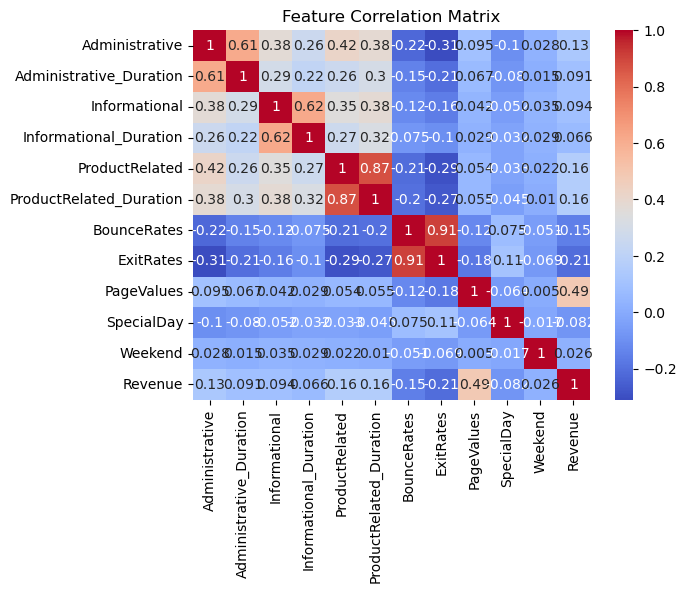

In [15]:
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Feature Correlation Matrix")
plt.show()

Looking at the heat map, we can see that ``Revenue`` and ``PageValues`` seems to be moderately correlated. 
\
Other features the pairs ExitRate-BounceRate, ProductRelated-ProductRelated_Duration, Informational-Informational-Duration I mean are obviously correlated since they are referring to the same events

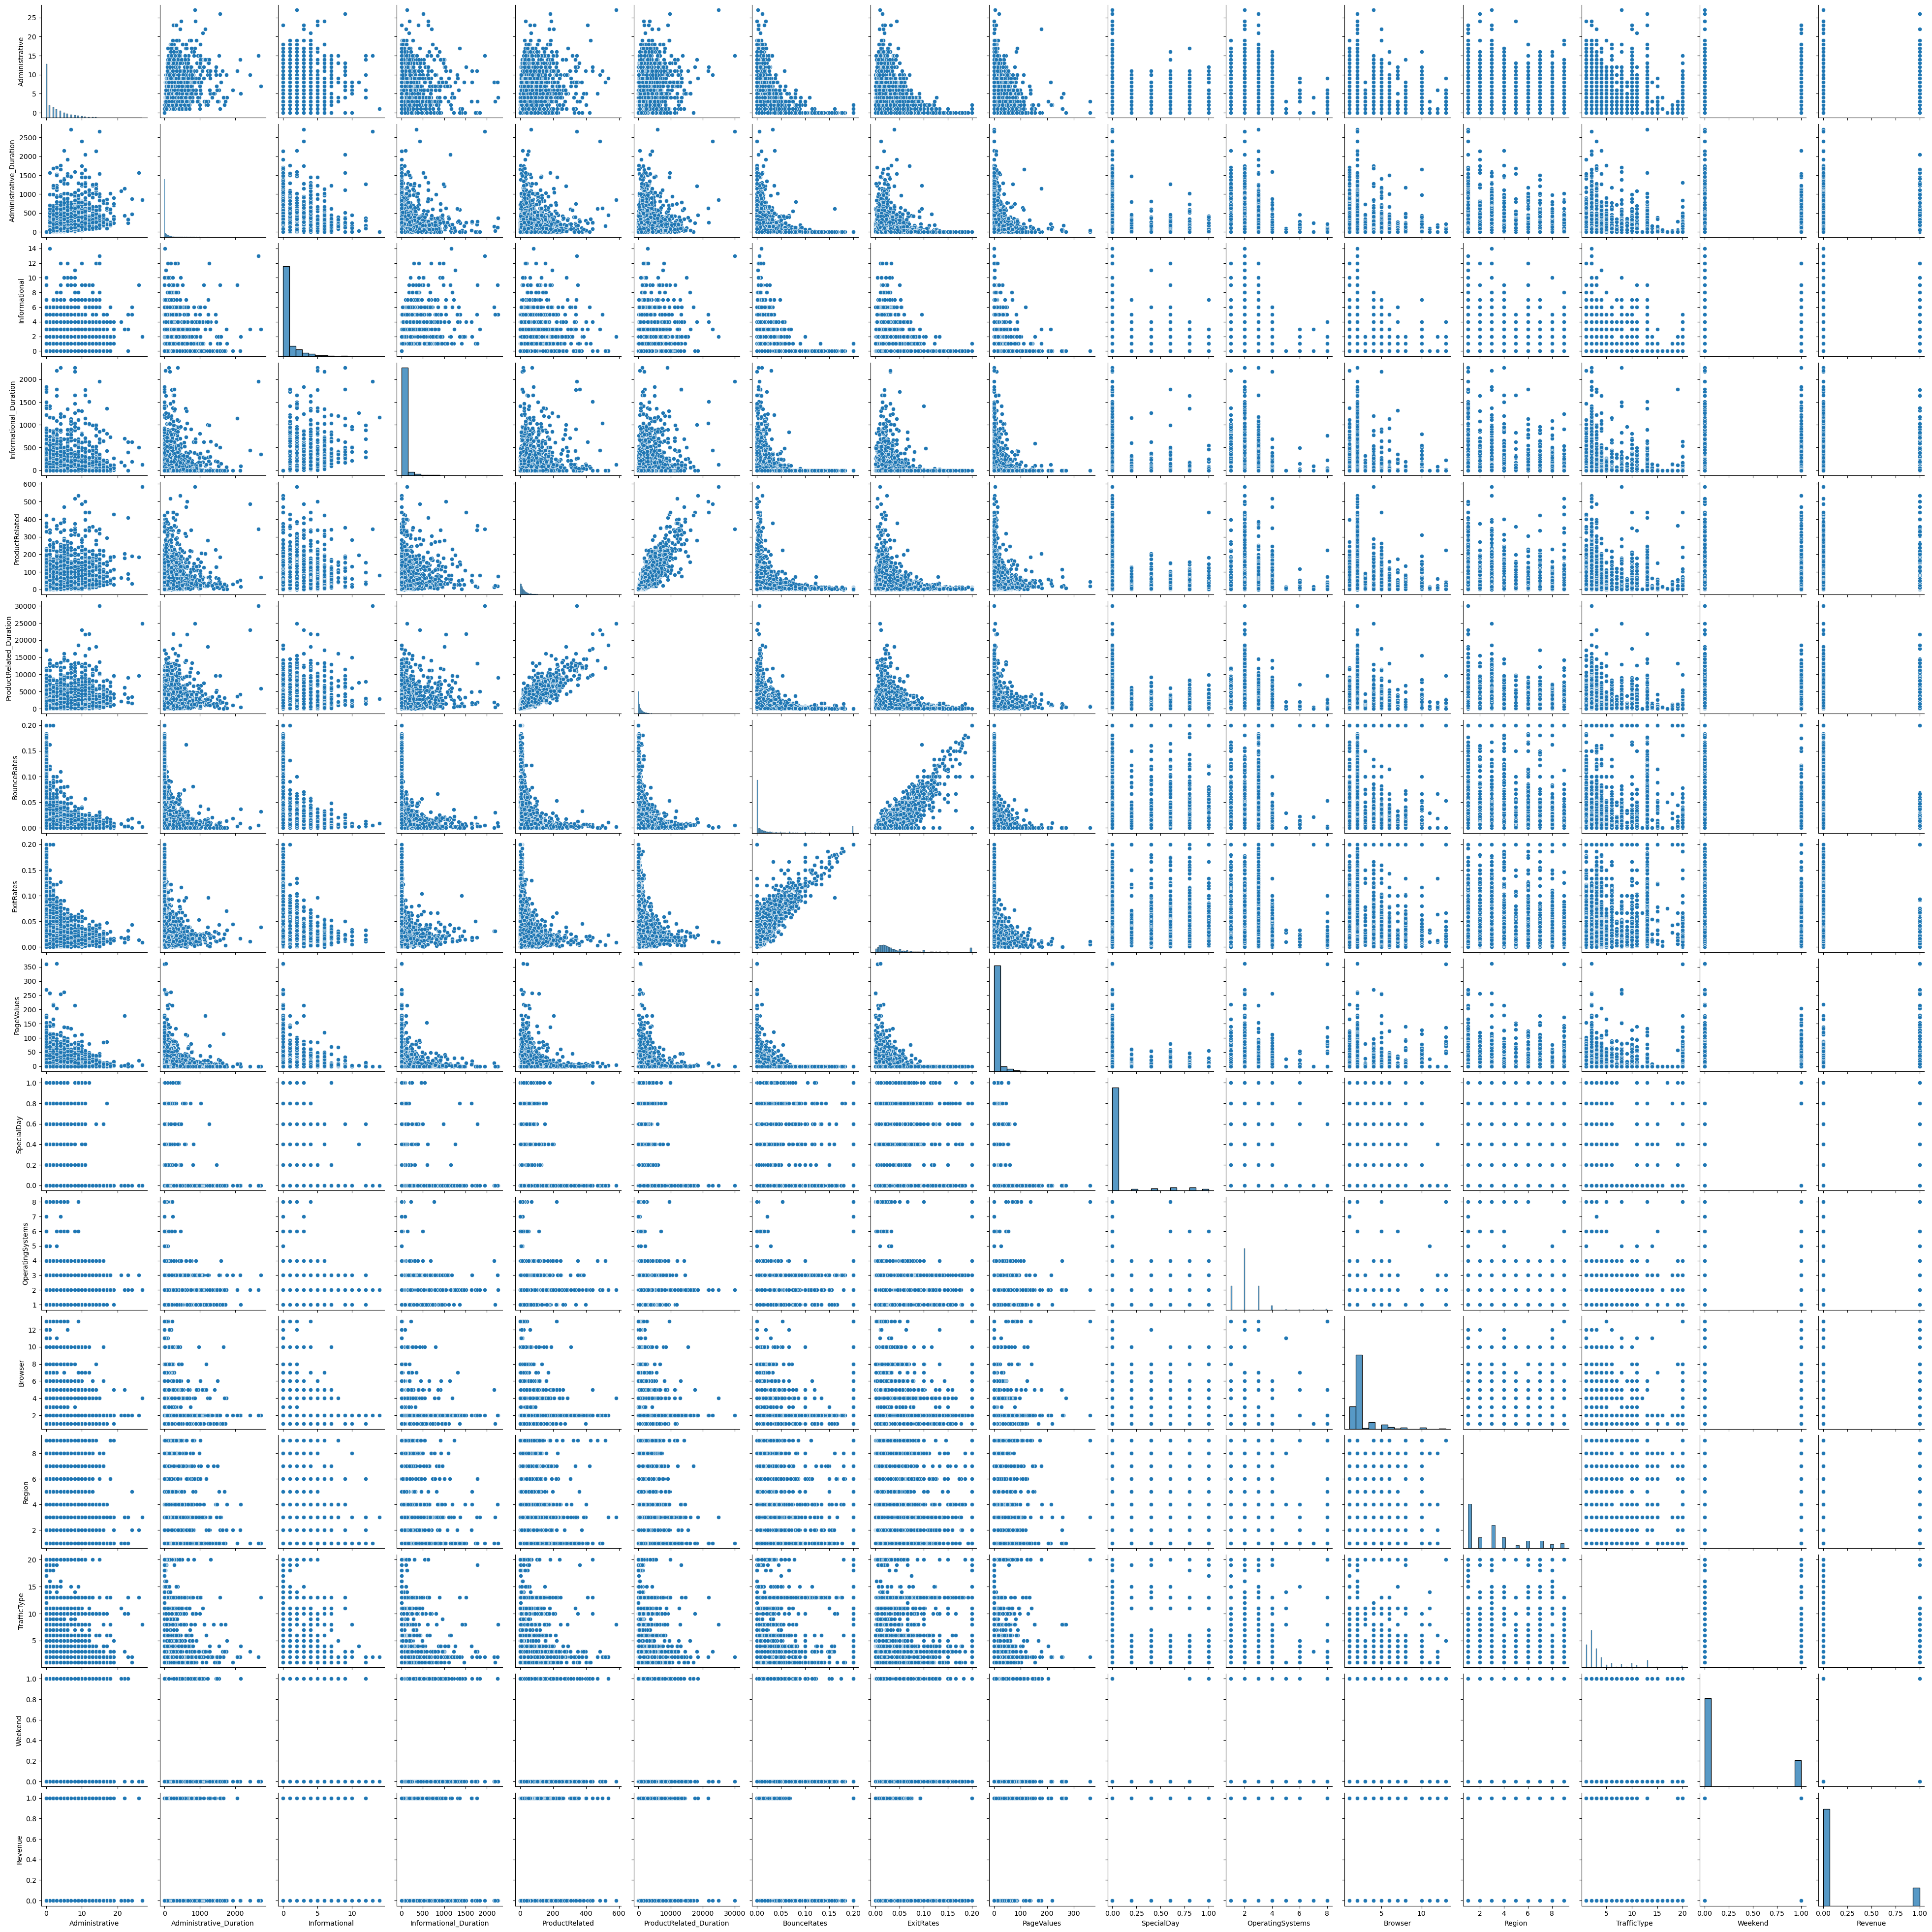

In [16]:
sns.pairplot(exp_data, height=2.5)
plt.show()

In [17]:
exp_data['Revenue'].value_counts()

Revenue
False    7807
True     1441
Name: count, dtype: int64

<Axes: xlabel='Revenue', ylabel='count'>

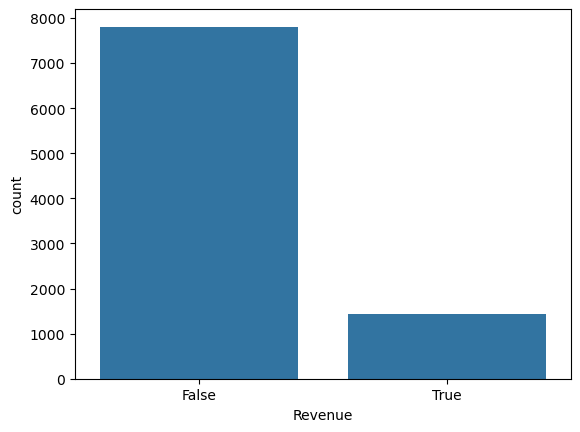

In [18]:
sns.countplot(x='Revenue', data=exp_data)
plt.show()

The target variable ``Revenue`` exhibits a clear class imbalance, with False representing the majority (7807 samples) and True the minority (1441 samples). Given this distribution, accuracy is not a reliable metric. Therefore, I will prioritize metrics like the F1-Score and utilize stratified splitting to maintain class proportions across training and test sets, ensuring the model is evaluated fairly on its ability to detect purchasing intent.

## Distribution of Features

### Continuous Features

<Axes: xlabel='Revenue', ylabel='Administrative'>

Text(0.5, 1.0, 'Boxplot of Administrative')

<Axes: xlabel='Revenue', ylabel='Administrative_Duration'>

Text(0.5, 1.0, 'Boxplot of Administrative_Duration')

<Axes: xlabel='Revenue', ylabel='Informational'>

...

Text(0.5, 1.0, 'Boxplot of BounceRates')

<Axes: xlabel='Revenue', ylabel='ExitRates'>

Text(0.5, 1.0, 'Boxplot of ExitRates')

<Axes: xlabel='Revenue', ylabel='PageValues'>

Text(0.5, 1.0, 'Boxplot of PageValues')

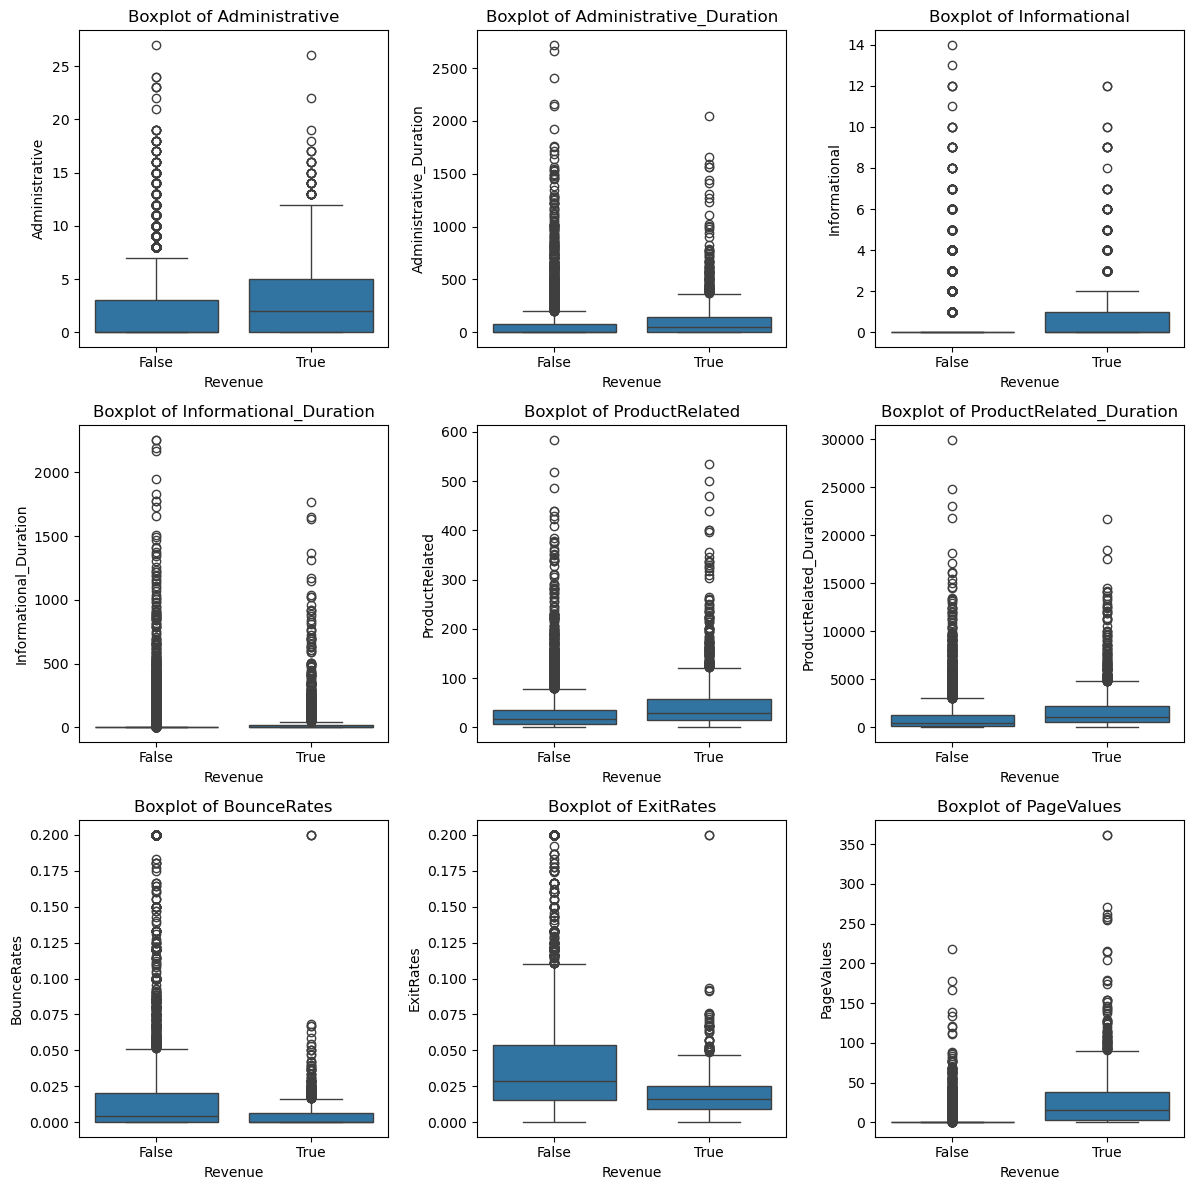

In [19]:
#boxplot a continuos variable and consider if it has outliers and everything: 
continuous = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
             'BounceRates', 'ExitRates', 'PageValues']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
plt.subplots_adjust(hspace=0.4)

for i, name in enumerate(continuous):
    row = i // 3
    col = i % 3
    ax = axes[row, col]
    sns.boxplot(data=exp_data, x="Revenue", y=name, ax=ax)
    ax.set_title("Boxplot of {}".format(name))

plt.tight_layout()
plt.show()

<Axes: xlabel='Administrative', ylabel='Count'>

Text(0.5, 1.0, 'Administrative')

<Axes: xlabel='Administrative_Duration', ylabel='Count'>

Text(0.5, 1.0, 'Administrative_Duration')

<Axes: xlabel='Informational', ylabel='Count'>

...

Text(0.5, 1.0, 'BounceRates')

<Axes: xlabel='ExitRates', ylabel='Count'>

Text(0.5, 1.0, 'ExitRates')

<Axes: xlabel='PageValues', ylabel='Count'>

Text(0.5, 1.0, 'PageValues')

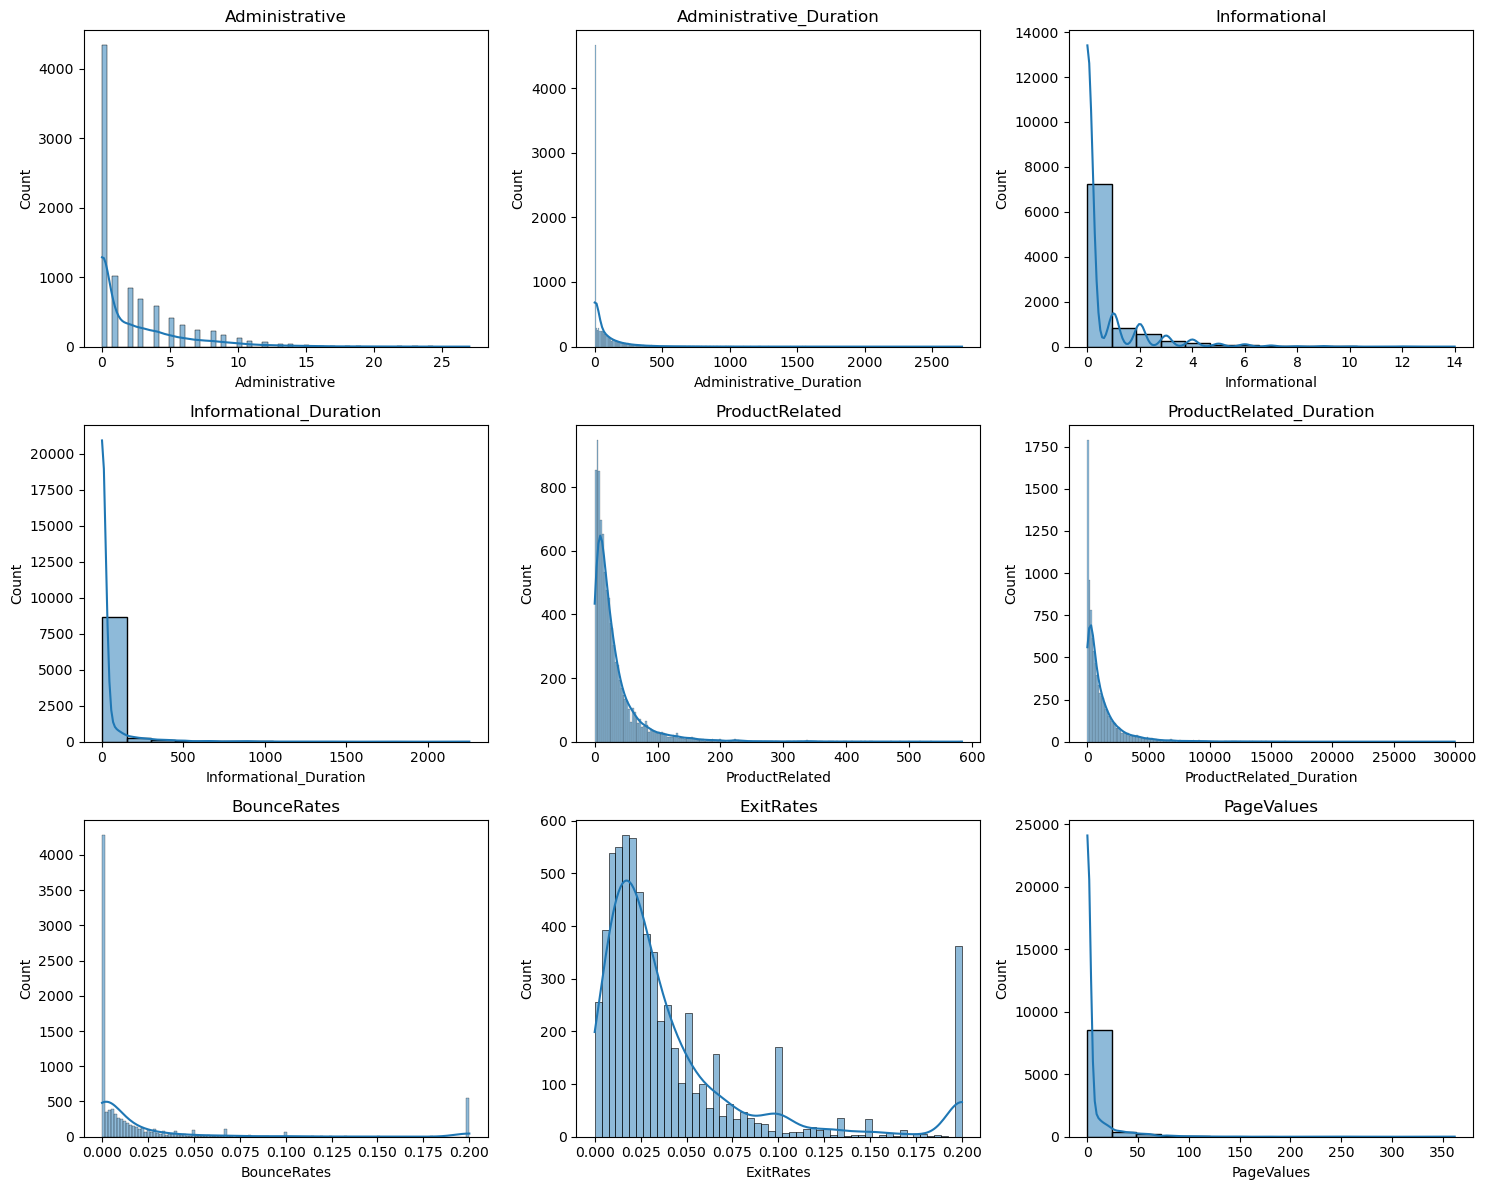

In [20]:
#distribution for the continous feature
cont_cols = ['Administrative', 'Administrative_Duration', 'Informational',
             'Informational_Duration', 'ProductRelated', 
             'ProductRelated_Duration', 'BounceRates', 'ExitRates', 
             'PageValues']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
for ax, col in zip(axes.flatten(), cont_cols):
    sns.histplot(exp_data[col].dropna(), kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### Categorical Variables

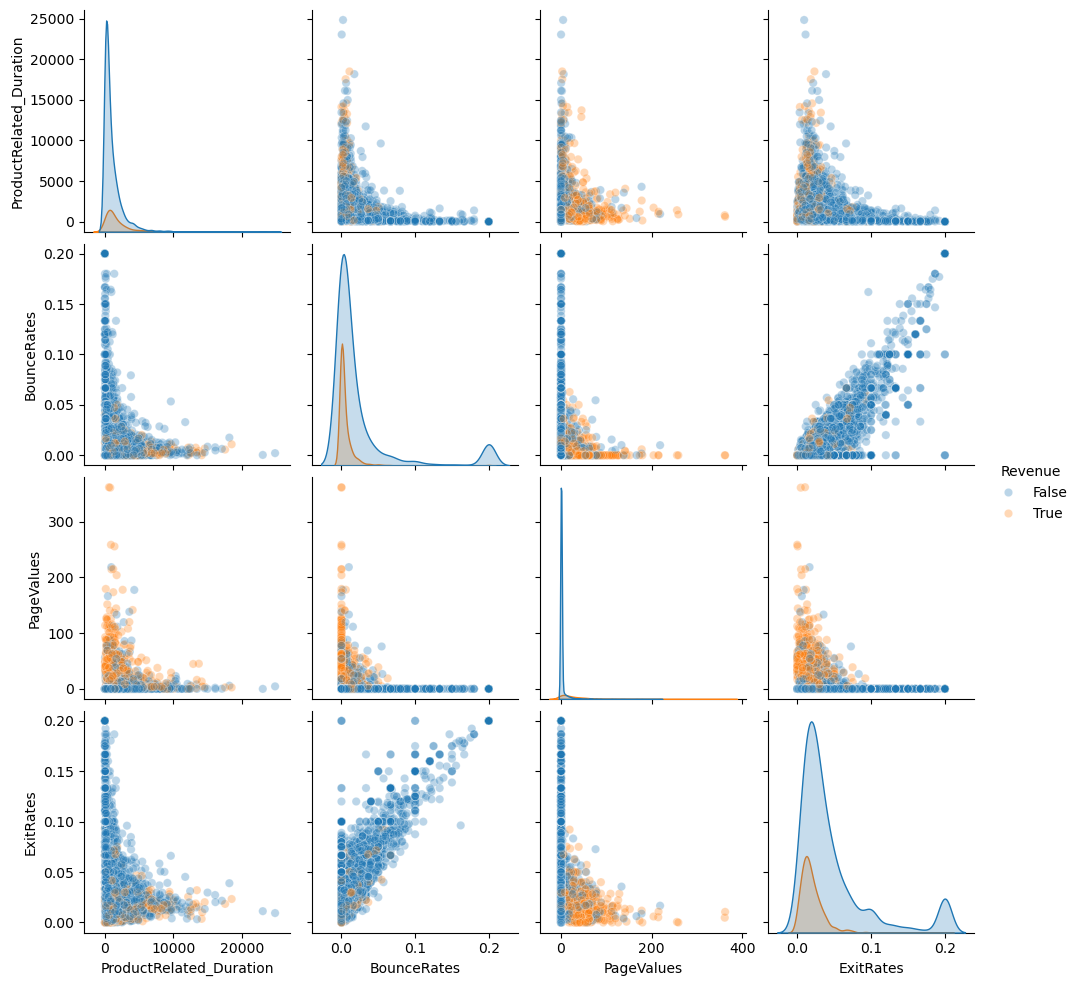

In [21]:
subset = ['ProductRelated_Duration', 'BounceRates', 'PageValues', 'ExitRates', 'Revenue']
sns.pairplot(exp_data[subset].dropna(), hue='Revenue', diag_kind='kde', plot_kws={'alpha':0.3})
plt.show()

#as expected highly correalted variable have a lienar relationshiè 

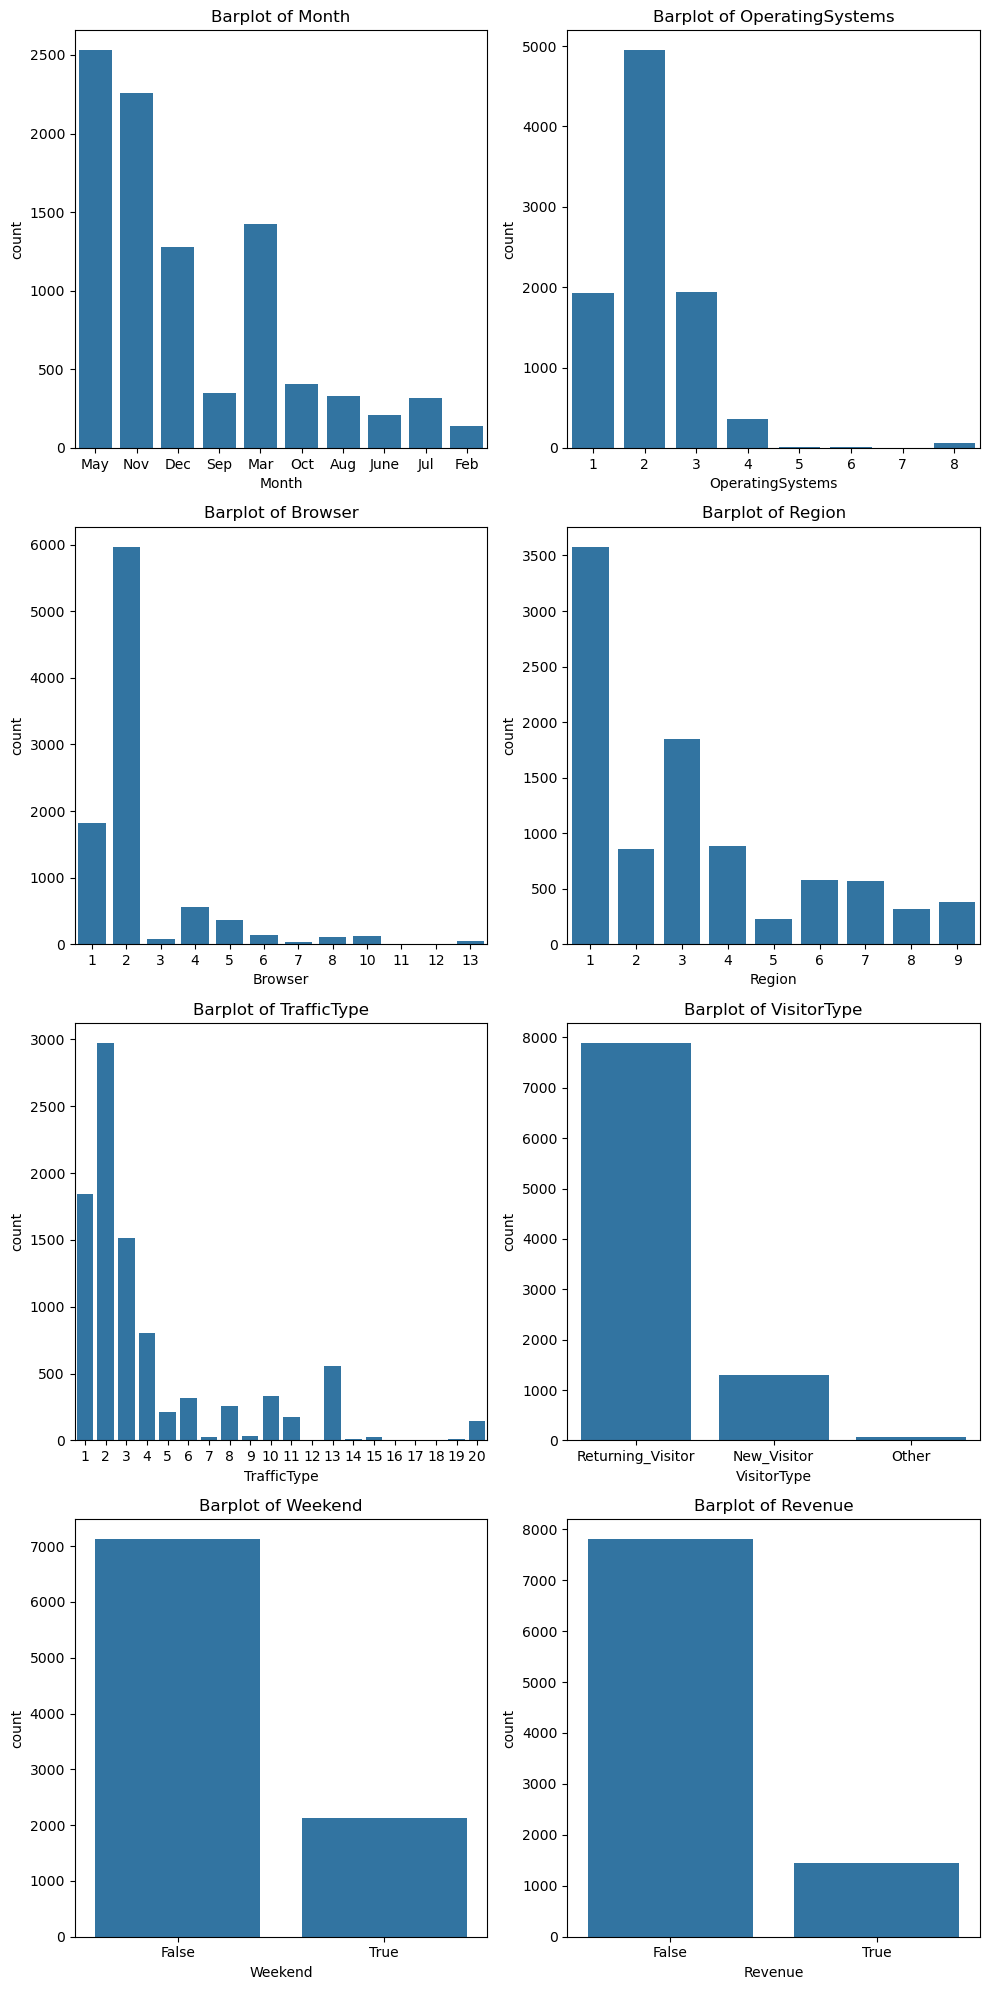

In [22]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(10, 20))
categoricals = ['Month','OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType','Weekend', 'Revenue']
for name in enumerate(categoricals):
    i, name = name
    sns.countplot(data=exp_data, x=name, ax=axes[i // 2, i % 2])
    axes[i // 2, i % 2].set_title("Barplot of {}".format(name))

plt.tight_layout()
plt.show();

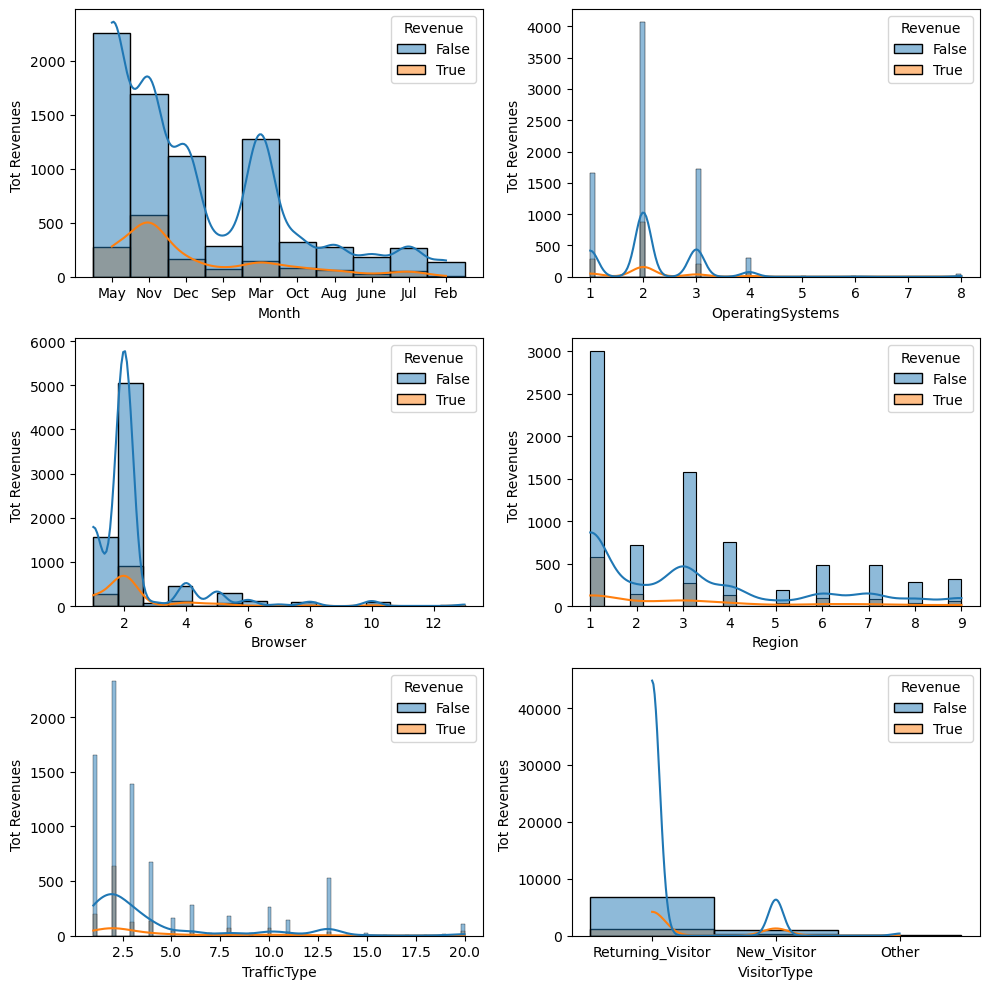

In [23]:
#some barplots for the total number of revenues (total number of true and false revenues) in the different categorical data: 
categorical_columns = ["OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]
exp_data[categorical_columns] = exp_data[categorical_columns].astype("category")
# COLONNE DA METTERE COME CATEGORICHE: Operating System, Browser, Region, Traffic Type, Visitor Type
# Columns month to be set as an ordered category
month_order = ['Feb','Mar','May','June','Jul','Aug','Sep','Oct','Nov','Dec']
month_dtype = pd.CategoricalDtype(categories=month_order, ordered=True)
exp_data['Month'] = exp_data['Month'].astype(month_dtype)

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(10, 10))
plt.subplots_adjust(hspace=0.4)

categoricals = ["Month", "OperatingSystems", "Browser", "Region", "TrafficType", "VisitorType"]

for i, categorical in enumerate(categoricals):
    ax = axes[i // 2, i % 2]  # Assign the correct axes to 'ax'
    sns.histplot(data=train_data, x=categorical, hue="Revenue", kde=True, ax=ax)
    ax.set_xlabel(categorical)
    ax.set_ylabel("Tot Revenues ")

plt.tight_layout()
plt.show();

---
---

## 1.2 Exit Rate Variable

How many missing values do I have in my training set and in my test set?

## Encoding

In [24]:
#For TRAINING set
#one-hot encoing for 'Month'
month_map = {
    "Jan": 1, "Feb": 2, "Mar": 3, "Apr": 4,
    "May": 5, "June": 6, "Jul": 7, "Aug": 8,
    "Sep": 9, "Oct": 10, "Nov": 11, "Dec": 12
} 
train_data['Month'] = train_data['Month'] .map(month_map)
train_data = pd.get_dummies(train_data, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType"])
train_data["Revenue"] = train_data["Revenue"].astype(int)
train_data["Weekend"] = train_data["Weekend"].astype(int)
train_data["month_sin"] = np.sin(2 * np.pi * train_data['Month'] / 12)
train_data["month_cos"] = np.cos(2 * np.pi * train_data['Month'] / 12)


test_data['Month'] = test_data['Month'] .map(month_map)
test_data = pd.get_dummies(test_data, columns=["OperatingSystems","Browser","Region","TrafficType","VisitorType"])
test_data["Revenue"] = test_data["Revenue"].astype(int)
test_data["Weekend"] = test_data["Weekend"].astype(int)
test_data["month_sin"] = np.sin(2 * np.pi * test_data['Month'] / 12)
test_data["month_cos"] = np.cos(2 * np.pi * test_data['Month'] / 12)

In [25]:
#re-allinging the column for the test set 
#saving the columns
train_cols = train_data.columns
#reallining: 
test_data = test_data.reindex(columns=train_cols, fill_value=0)

In [26]:
train_data.isna().sum().sort_values(ascending=False)
test_data.isna().sum().sort_values(ascending=False)

train_data.columns

ExitRates         2782
Administrative       0
TrafficType_1        0
TrafficType_7        0
TrafficType_6        0
                  ... 
Browser_8            0
Browser_10           0
Browser_11           0
Browser_12           0
month_cos            0
Length: 67, dtype: int64

ExitRates         917
Administrative      0
TrafficType_1       0
TrafficType_7       0
TrafficType_6       0
                 ... 
Browser_8           0
Browser_10          0
Browser_11          0
Browser_12          0
month_cos           0
Length: 67, dtype: int64

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'Weekend', 'Revenue', 'OperatingSystems_1', 'OperatingSystems_2',
       'OperatingSystems_3', 'OperatingSystems_4', 'OperatingSystems_5',
       'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8',
       'Browser_1', 'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5',
       'Browser_6', 'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11',
       'Browser_12', 'Browser_13', 'Region_1', 'Region_2', 'Region_3',
       'Region_4', 'Region_5', 'Region_6', 'Region_7', 'Region_8', 'Region_9',
       'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4',
       'TrafficType_5', 'TrafficType_6', 'TrafficType_7', 'TrafficType_8',
       'TrafficType_9', 'TrafficType_10', 'TrafficType_11', 'TrafficType_12',
       'TrafficType_13', 'TrafficType_

---

## Regression

To predict ``ExitRates`` missing values, we trained different regression algorithms:
- Linear regression
- Ridge
- Lasso
- Random Forest

Hyper parameter tuning

In [27]:
copied_train = train_data[train_data['ExitRates'].notna()]

In [28]:
X = copied_train.drop(['ExitRates', 'Revenue'], axis=1)
y = copied_train['ExitRates']

print(X.columns)

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'PageValues', 'SpecialDay', 'Month', 'Weekend',
       'OperatingSystems_1', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6',
       'OperatingSystems_7', 'OperatingSystems_8', 'Browser_1', 'Browser_2',
       'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7',
       'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
       'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
       'Region_7', 'Region_8', 'Region_9', 'TrafficType_1', 'TrafficType_2',
       'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_6',
       'TrafficType_7', 'TrafficType_8', 'TrafficType_9', 'TrafficType_10',
       'TrafficType_11', 'TrafficType_12', 'TrafficType_13', 'TrafficType_14',
       'TrafficType_15', '

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer

r2_score = make_scorer(r2_score, greater_is_better=True)
mean_squared_error = make_scorer(mean_squared_error, greater_is_better=True)


results = {}

### Multiple regression

In [30]:
from sklearn.linear_model import LinearRegression 

MultipleRegression = LinearRegression(fit_intercept= True)
scores_MR = cross_val_score(MultipleRegression, X, y, cv = 5, scoring=mean_squared_error)
scores_MR
results['MultipleRegression'] = (float(scores_MR.mean().round(4)), float(scores_MR.std().round(4)))

array([0.00040549, 0.00030345, 0.00032661, 0.00031313, 0.00027095])

### Forward Feature Selection

In [31]:
#forward feature selection
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    MultipleRegression,
    n_features_to_select= 'auto',       
    direction="forward",
    scoring= 'neg_mean_squared_error',                  
    cv=5,                          
    n_jobs=-1                       
)

sfs_forward.fit(X, y)
selected_mask = sfs_forward.get_support()
selected_indices = np.where(selected_mask)[0]

print(selected_indices)

selected_features_FFS = X.columns[selected_mask]
print(list(selected_features_FFS))

SequentialFeatureSelector(estimator=LinearRegression(), n_jobs=-1,
                          scoring='neg_mean_squared_error')

[ 0  1  2  4  5  6  7  8  9 12 16 17 19 23 28 36 37 39 40 41 42 43 46 51
 52 53 55 56 58 60 63 64]
['Administrative', 'Administrative_Duration', 'Informational', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems_2', 'OperatingSystems_6', 'OperatingSystems_7', 'Browser_1', 'Browser_5', 'Browser_11', 'Region_6', 'Region_7', 'Region_9', 'TrafficType_1', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_7', 'TrafficType_12', 'TrafficType_13', 'TrafficType_14', 'TrafficType_16', 'TrafficType_17', 'TrafficType_19', 'VisitorType_New_Visitor', 'month_sin', 'month_cos']


### Lasso

In [32]:
#3.Lasso:
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(random_state=42))
])

param_grid = {
    'lasso__alpha': np.logspace(-4, 1, 50)
}

# Inner CV: seleziona il miglior alpha
grid_lasso = GridSearchCV(
    pipe,
    param_grid=param_grid,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)

# Outer CV: valuta le performance in modo onesto (nested CV)
scores_lasso = cross_val_score(grid_lasso, X, y, cv=5, scoring= mean_squared_error)
results['Lasso'] = (float(scores_lasso.mean().round(4)), float(scores_lasso.std().round(4)))

### Ridge Regression

In [33]:
#4. Ridge Regression
from sklearn.linear_model import Ridge


pipe_ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(random_state=42))
])

param_grid_ridge = {
    'ridge__alpha': np.logspace(-4, 1, 50)
}

# Inner CV: seleziona il miglior alpha
grid_ridge = GridSearchCV(
    pipe_ridge,
    param_grid=param_grid_ridge,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)

# Outer CV: valuta le performance in modo onesto (nested CV)
scores_ridge = cross_val_score(grid_ridge, X, y, cv=5, scoring=mean_squared_error)
results['Ridge'] = (float(scores_ridge.mean().round(4)), float(scores_ridge.std().round(4)))

### Random Forest

In [34]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

""" param_grid = {
    "n_estimators": [100, 200, 500],
    "max_depth": [10, 20, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", 0.5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring= mean_squared_error,
    n_jobs=-1
)
scores_rf = cross_val_score(
    grid_rf,
    X,
    y,
    cv=5,
    scoring= mean_squared_error
)

results['RandomForest'] = (
    float(scores_rf.mean().round(4)),
    float(scores_rf.std().round(4))
) """

' param_grid = {\n    "n_estimators": [100, 200, 500],\n    "max_depth": [10, 20, None],\n    "min_samples_leaf": [1, 2, 5],\n    "max_features": ["sqrt", 0.5]\n}\n\ngrid_rf = GridSearchCV(\n    RandomForestRegressor(random_state=42),\n    param_grid=param_grid,\n    cv=5,\n    scoring= mean_squared_error,\n    n_jobs=-1\n)\nscores_rf = cross_val_score(\n    grid_rf,\n    X,\n    y,\n    cv=5,\n    scoring= mean_squared_error\n)\n\nresults[\'RandomForest\'] = (\n    float(scores_rf.mean().round(4)),\n    float(scores_rf.std().round(4))\n) '

In [35]:
grid_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

scores_rf = cross_val_score(
    grid_rf,
    X,
    y,
    cv=5,
    scoring= mean_squared_error
)

results['RandomForest'] = (
    float(scores_rf.mean().round(4)),
    float(scores_rf.std().round(4))
)

In [36]:
pd.DataFrame(results, ['MSE', 'std'])

,MultipleRegression,Lasso,Ridge,RandomForest
MSE,0.0003,0.0023,0.0003,0.0002
std,0.0000,0.0002,0.0000,0.0000


## Results for regression

Text(0, 0.5, 'Mean Squared Error')

Text(0.5, 1.0, 'Confronto modelli: MSE (mean ± std)')

[Text(0, 0, 'MultipleRegression'),
 Text(1, 0, 'Lasso'),
 Text(2, 0, 'Ridge'),
 Text(3, 0, 'RandomForest')]

Text(0.0, 0.0003, '0.0003')

Text(1.0, 0.0023, '0.0023')

Text(2.0, 0.0003, '0.0003')

Text(3.0, 0.0002, '0.0002')

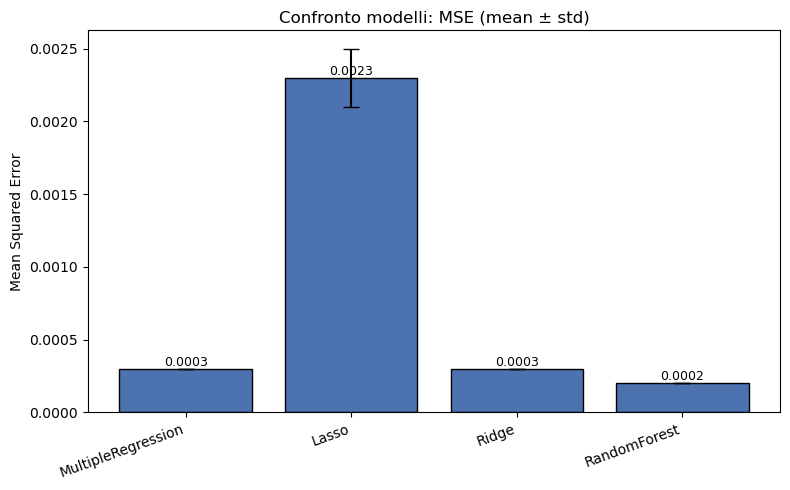

In [37]:
#results for regression algorithms:
keys = list(results.keys())
means = [v[0] for v in results.values()]
stds = [v[1] for v in results.values()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(keys, means, yerr=stds, capsize=6, color="#4C72B0", edgecolor="black")

ax.set_ylabel("Mean Squared Error")
ax.set_title("Confronto modelli: MSE (mean ± std)")
ax.set_xticks(range(len(keys)))
ax.set_xticklabels(keys, rotation=20, ha="right")

for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(), f"{mean:.4f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("mse_barplot.png", dpi=150)
plt.show()


the random forest seems to work pretty well compare to the others so we will process to fill the NaN 
the only drawback for the random forest approch is to not be so clear to understand how it works but we will use it for prediction so we are more concearned about precision in the prediction
so we choose the one with the lowerest mean squared error and std in the model tested!
first we extract the best parameter and fit the best model that we are gonna use:

In [38]:

""" grid_rf.fit(X, y)

print(grid_rf.best_params_)
print(grid_rf.best_score_) """

' grid_rf.fit(X, y)\n\nprint(grid_rf.best_params_)\nprint(grid_rf.best_score_) '

In [39]:
""" #building the random forest model with the best parameters
best_model = RandomForestRegressor(
    **grid_rf.best_params_, #selecting the best parameters
    random_state=42,
    n_jobs=-1
)

#fitting the model 
best_model.fit(X,y) """

' #building the random forest model with the best parameters\nbest_model = RandomForestRegressor(\n    **grid_rf.best_params_, #selecting the best parameters\n    random_state=42,\n    n_jobs=-1\n)\n\n#fitting the model \nbest_model.fit(X,y) '

In [40]:
best_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

best_model.fit(X,y)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

----
---
---

# Task 2
_Use the regression model trained at the previous step to recover the Exit Rate by predicting its value for each missing sample on the train and test set. Build a classification model to predict whether an online shopper is likely to make a purchase. Perform feature selection, compare different algorithms, and identify the one that works the best on this dataset. Finally, test the best algorithm’s performance on the provided test set. Determine whether a model built using the Exit Rate information is better than a model built using the remaining features._

**2.1 Recovering ExitRates** \
**2.2 Classification (with and without feature selection)** \
**2.3 Feature selection**:
- Logistic lasso 

**2.4 Performance on test set**

## 2.1 Filling NAs 

## Feature set

In [41]:
#filling the NaN:
print('before')
train_data.isna().sum().sort_values(ascending=False) 
#selecting the NaN value that we are gonna predict with all the feature present in the dataset
X_test = train_data.loc[
    train_data['ExitRates'].isna(),
    X.columns
]
#computing the prediciton given that X
pred = best_model.predict(X_test)
#assigning the prediction to the correspondet NaN in the training dataset:
train_data.loc[train_data['ExitRates'].isna(), 'ExitRates'] = pred
print('after')
#after
train_data.isna().sum().sort_values(ascending=False) 

before


ExitRates         2782
Administrative       0
TrafficType_1        0
TrafficType_7        0
TrafficType_6        0
                  ... 
Browser_8            0
Browser_10           0
Browser_11           0
Browser_12           0
month_cos            0
Length: 67, dtype: int64

after


Administrative    0
TrafficType_9     0
Region_4          0
Region_5          0
Region_6          0
                 ..
Browser_8         0
Browser_10        0
Browser_11        0
Browser_12        0
month_cos         0
Length: 67, dtype: int64

In [42]:
#now we train the random forest with all the observation and our dataset to have a complete model to be used for predicting the 'Exit Rate' feature in the test set:
X_full = train_data[X.columns]
y_full = train_data['ExitRates']

#fitting the model 
best_model.fit(X_full,y_full)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

In [43]:
#filling the NaN in the test set:
X_test = test_data.loc[
    test_data['ExitRates'].isna(),
    X.columns
]
#computing the prediciton given that X
pred = best_model.predict(X_test)
#assigning the prediction to the correspondet NaN in the training dataset:
test_data.loc[test_data['ExitRates'].isna(), 'ExitRates'] = pred
print('after')
#after
test_data.isna().sum().sort_values(ascending=False) 

after


Administrative    0
TrafficType_9     0
Region_4          0
Region_5          0
Region_6          0
                 ..
Browser_8         0
Browser_10        0
Browser_11        0
Browser_12        0
month_cos         0
Length: 67, dtype: int64

## Feature Selection

### Lasso

In [44]:
#We need to build a classfication using only the most relevant feature, so before trying diffent clasfication methods to predict the 'Revenue' we will first select the 
#most import variable that are usefull in our problem
#we choose to first apply feature selection and extract the relevant feature with a logistic model using the l1 penalizzation (LASSO), and then test for different classifier
#this allow to reduce the complexity of the next model we will fit and help to make the model more interpretable:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

X_all_feature = ['Administrative', 'Administrative_Duration',
       'Informational', 'Informational_Duration', 'ProductRelated',
       'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues',
       'SpecialDay', 'Weekend', 'month_sin', 'month_cos',
       'VisitorType_Other', 'VisitorType_Returning_Visitor', 'Browser_2',
       'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6', 'Browser_7',
       'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
       'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6', 'Region_7',
       'Region_8', 'Region_9', 'TrafficType_2', 'TrafficType_3',
       'TrafficType_4', 'TrafficType_5', 'TrafficType_6', 'TrafficType_7',
       'TrafficType_8', 'TrafficType_9', 'TrafficType_10', 'TrafficType_11',
       'TrafficType_12', 'TrafficType_13', 'TrafficType_14', 'TrafficType_15',
       'TrafficType_16', 'TrafficType_17', 'TrafficType_18', 'TrafficType_19',
       'TrafficType_20', 'OperatingSystems_2', 'OperatingSystems_3',
       'OperatingSystems_4', 'OperatingSystems_5', 'OperatingSystems_6',
       'OperatingSystems_7', 'OperatingSystems_8']
#definition of the variables:
y = train_data['Revenue']
X = train_data[X_all_feature]

#cross validation to decide with penalty value is the best to use
C_values = [0.001, 0.01, 0.1, 1, 10, 100]
C_scores = {}

for C in C_values:

    model = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                penalty="l1",
                                C=C,
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced" ))]) #in order to take into account the fact that the class 1 for revenue is not balanced

    scores= cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring= "f1")
    
    model.fit(X, y)
    
    lasso_model = model.named_steps['lasso']

    n_zero = np.sum(lasso_model.coef_ == 0) 

    C_scores[C] = (float(scores.mean().round(4)), float(n_zero))
print(C_scores)


Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=1, class_weight='balanced', max_iter=1000,
                                    penalty='l1', solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=10, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=100, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

{0.001: (0.6519, 58.0), 0.01: (0.632, 44.0), 0.1: (0.6066, 9.0), 1: (0.6033, 1.0), 10: (0.6019, 0.0), 100: (0.6017, 0.0)}


### Forward Feature Selection

In [45]:
#forward feature selection
from sklearn.feature_selection import SequentialFeatureSelector

sfs_forward = SequentialFeatureSelector(
    MultipleRegression,
    n_features_to_select= 'auto',       
    direction="forward",
    scoring= 'neg_mean_squared_error',                  
    cv=5,                          
    n_jobs=-1                       
)

sfs_forward.fit(X, y)
selected_mask = sfs_forward.get_support()
selected_indices = np.where(selected_mask)[0]

print(selected_indices)

selected_features_FFS = X.columns[selected_mask]
print(list(selected_features_FFS))

SequentialFeatureSelector(estimator=LinearRegression(), n_jobs=-1,
                          scoring='neg_mean_squared_error')

[ 2  4  5  6  7  8 11 12 14 15 16 18 19 26 30 32 33 35 41 42 43 44 45 46
 47 48 49 53 57 58]
['Informational', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'month_sin', 'month_cos', 'VisitorType_Returning_Visitor', 'Browser_2', 'Browser_3', 'Browser_5', 'Browser_6', 'Region_2', 'Region_6', 'Region_8', 'Region_9', 'TrafficType_3', 'TrafficType_9', 'TrafficType_10', 'TrafficType_11', 'TrafficType_12', 'TrafficType_13', 'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_17', 'OperatingSystems_2', 'OperatingSystems_6', 'OperatingSystems_7']


In [46]:
#we don't have a lot of diverty in the f1 for each model, so taking into account the fact that we have a lot of variable we will go with the value of C = 0.01 that is
#between all the value that we trying in order to obtain a much simpler model to compare:
#even if is not the best accuracy we choose a model with only the essential feature in order to have something more interpretable

Logist_Lasso = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                penalty="l1",
                                C=0.01,
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced"))])

Logist_Lasso.fit(X,y)

lasso_model = Logist_Lasso.named_steps['lasso']

coef = lasso_model.coef_.ravel()

selected_features_LASSO = np.array(X_all_feature)[np.abs(coef) > 1e-6]

print(selected_features_LASSO)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(C=0.01, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
                                    solver='liblinear'))])

['Administrative' 'Informational' 'ProductRelated'
 'ProductRelated_Duration' 'ExitRates' 'PageValues' 'month_sin'
 'month_cos' 'Region_9' 'TrafficType_2' 'TrafficType_3' 'TrafficType_8'
 'TrafficType_10' 'TrafficType_11' 'TrafficType_13' 'TrafficType_20']


In [47]:
import pandas as pd
from sklearn.feature_selection import SelectFromModel

# Assuming you have something like:
# rf = RandomForestRegressor(random_state=42)
grid_rf.fit(X, y)

importances = pd.Series(grid_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Select features above the median importance (or 'mean', or a specific float threshold)
selector = SelectFromModel(grid_rf, threshold='median', prefit=True)
selected_mask = selector.get_support()

selected_features_rf = X.columns[selected_mask].tolist()
print(selected_features_rf)

RandomForestRegressor(max_depth=10, max_features='sqrt', min_samples_leaf=5,
                      n_estimators=200, n_jobs=-1, random_state=42)

['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Weekend', 'month_sin', 'month_cos', 'VisitorType_Returning_Visitor', 'Browser_2', 'Browser_4', 'Region_2', 'Region_3', 'Region_4', 'Region_6', 'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5', 'TrafficType_8', 'TrafficType_10', 'TrafficType_13', 'TrafficType_20', 'OperatingSystems_2', 'OperatingSystems_3']


In [48]:
feature_sets_clf = {
    'All features': X.columns.tolist(),
    'RF selected': selected_features_rf,
    'Lasso-LR selected': selected_features_LASSO,
    'Forward selected': selected_features_FFS,
}

In [49]:
from sklearn.model_selection import cross_validate, KFold
from sklearn.ensemble import RandomForestRegressor
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.pipeline import Pipeline


clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'SVM': SVC(class_weight='balanced', probability=True),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_clf_fs = []

for fs_name, feats in feature_sets_clf.items():
    for model_name, model in clf_models.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        scores = cross_validate(
            pipe, X[feats], y,
            cv=skf,
            scoring=['accuracy', 'f1', 'roc_auc']
        )
        results_clf_fs.append({
            'Feature Set': fs_name,
            'Model': model_name,
            'n_features': len(feats),
            'Accuracy': scores['test_accuracy'].mean(),
            'F1': scores['test_f1'].mean(),
            'ROC_AUC': scores['test_roc_auc'].mean()
        })

results_clf_fs_df = pd.DataFrame(results_clf_fs)
print(results_clf_fs_df.pivot(index='Feature Set', columns='Model', values='F1'))

kf = KFold(n_splits=5, shuffle=True, random_state=42)

clf_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'LDA': LinearDiscriminantAnalysis(),
    'QDA': QuadraticDiscriminantAnalysis(reg_param=0.1),
    'Random Forest': RandomForestClassifier(random_state=42, class_weight='balanced'),
    'SVM': SVC(class_weight='balanced', probability=True),
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_clf_fs = []

for fs_name, feats in feature_sets_clf.items():
    for model_name, model in clf_models.items():
        pipe = Pipeline([
            ('scaler', StandardScaler()),
            ('model', model)
        ])
        scores = cross_validate(
            pipe, X[feats], y,
            cv=skf,
            scoring=['accuracy', 'f1', 'roc_auc']
        )
        results_clf_fs.append({
            'Feature Set': fs_name,
            'Model': model_name,
            'n_features': len(feats),
            'Accuracy': scores['test_accuracy'].mean(),
            'F1': scores['test_f1'].mean(),
            'ROC_AUC': scores['test_roc_auc'].mean()
        })

results_clf_fs_df = pd.DataFrame(results_clf_fs)
print(results_clf_fs_df.pivot(index='Feature Set', columns='Model', values='F1'))

Model                   LDA  Logistic Regression       QDA  Random Forest  \
Feature Set                                                                 
All features       0.456811             0.599042  0.317077       0.594832   
Forward selected   0.455602             0.615239  0.310314       0.611341   
Lasso-LR selected  0.444104             0.609407  0.478433       0.620745   
RF selected        0.452513             0.607724  0.479867       0.619624   

Model                   SVM  
Feature Set                  
All features       0.590182  
Forward selected   0.612562  
Lasso-LR selected  0.615342  
RF selected        0.600184  


Exception ignored in: <function ResourceTracker.__del__ at 0x1072d1d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104b19d00>
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 82, in __del__
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 91, in _stop
  File "/opt/anaconda3/lib/python3.13/multiprocessing/resource_tracker.py", line 116, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x104861d00>
Traceback (most recent call last

Model                   LDA  Logistic Regression       QDA  Random Forest  \
Feature Set                                                                 
All features       0.456811             0.599042  0.317077       0.594832   
Forward selected   0.455602             0.615239  0.310314       0.611341   
Lasso-LR selected  0.444104             0.609407  0.478433       0.620745   
RF selected        0.452513             0.607724  0.479867       0.619624   

Model                   SVM  
Feature Set                  
All features       0.590182  
Forward selected   0.612562  
Lasso-LR selected  0.615342  
RF selected        0.600184  


Lasso-LR selected features achieve the best or near-best F1 and ROC-AUC across almost every model, using only 
16 features (73% fewer than the full 60-feature set) with negligible loss in performance — for Random Forest 
specifically, Lasso-selected features even slightly outperform the full feature set on F1 (0.621 vs 0.595) 
and ROC-AUC (0.924 vs 0.922), though RF-selected features give marginally higher accuracy (0.899 vs 0.895).

We select Lasso-LR features as our final feature set: beyond the strong performance, Lasso coefficients offer 
directly interpretable, signed linear effects on the target's log-odds, which we find easier to communicate 
than Random Forest's impurity-based importance scores.

In [50]:
results_clf_fs_df

,Feature Set,Model,n_features,Accuracy,F1,ROC_AUC
0,All features,Logistic Regression,60,0.845264,0.599042,0.893972
1,All features,LDA,60,0.877919,0.456811,0.892184
2,All features,QDA,60,0.366891,0.317077,0.773664
3,All features,Random Forest,60,0.895112,0.594832,0.922036
4,All features,SVM,60,0.845372,0.590182,0.882329
5,RF selected,Logistic Regression,30,0.849806,0.607724,0.897566
6,RF selected,LDA,30,0.877162,0.452513,0.894565
7,RF selected,QDA,30,0.808068,0.479867,0.805839
8,RF selected,Random Forest,30,0.898788,0.619624,0.922442
9,RF selected,SVM,30,0.848940,0.600184,0.886228


This table reports Accuracy, F1, and ROC-AUC for each combination of classifier and feature selection method, 
giving a general overview of performance across the board.

## Selected Features: Lasso

In [51]:
X_selected = train_data[selected_features_LASSO]
selected_features = selected_features_LASSO

given the size of the sample that we have we will fit different SVM model and
we will assess the quality only compare to the training set, then chonen the best 
thgourh the f1 score, we will fit that model and use the CV approach to have a 
mean result to compare with the other model.
The CV approach for all will be to long to perform in this case, given that that would have been the best approach:

---

# Classification models with selected features

In [52]:
#SVM
from sklearn.svm import SVC
param_grid_svc = [
    {'kernel': ['linear'],'C':[0.01, 0.1, 1, 10]},
    {'kernel': ['rbf'], 'C':[0.01, 0.1, 1, 10], 'gamma': ['scale', 'auto', 0.01, 0.1]},
    {'kernel': ['poly'], 'C': [0.01, 0.1, 1, 10], 'degree': [2,3,4], 'gamma':['scale', 'auto']},
]

#feature scaling
scaler = StandardScaler()
X_train_std_svc = scaler.fit_transform(X_selected)

grid_svc = GridSearchCV(SVC(), param_grid_svc, cv = 5, scoring = 'f1', n_jobs = -1)
grid_svc.fit(X_train_std_svc, y)
print(grid_svc.best_params_)

GridSearchCV(cv=5, estimator=SVC(), n_jobs=-1,
             param_grid=[{'C': [0.01, 0.1, 1, 10], 'kernel': ['linear']},
                         {'C': [0.01, 0.1, 1, 10],
                          'gamma': ['scale', 'auto', 0.01, 0.1],
                          'kernel': ['rbf']},
                         {'C': [0.01, 0.1, 1, 10], 'degree': [2, 3, 4],
                          'gamma': ['scale', 'auto'], 'kernel': ['poly']}],
             scoring='f1')

{'C': 10, 'gamma': 'auto', 'kernel': 'rbf'}


In [53]:
#now we will fit different classification model using only the selected feature:
from collections import OrderedDict

from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA, QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

# Define models

lda = LDA()
qda = QDA()

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

knn = KNeighborsClassifier(n_neighbors=11)

knn_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=16))
])

knn_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=17))
])

SVC_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced'
    ))
])

models = OrderedDict([
    ('LDA', lda),
    ('QDA', qda),
    ('Logistic Regression', log_reg),
    ('KNN', knn),
    ('KNN + StandardScaler', knn_std),
    ('KNN + MinMaxScaler', knn_minmax),
    ('SVC (best parameters)', SVC_best)
])

# Compare models (CV only)
scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(
        model, X_selected, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        row[metric] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    results_list.append(row)

results = pd.DataFrame(results_list)
results

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,model,accuracy,accuracy_std,f1,f1_std,roc_auc,roc_auc_std
0,LDA,0.876189,0.005868,0.446336,0.030185,0.900325,0.012241
1,QDA,0.821798,0.009462,0.493773,0.026379,0.824655,0.006246
2,Logistic Regression,0.858780,0.009973,0.619604,0.024489,0.902627,0.011413
3,KNN,0.873378,0.004833,0.450001,0.027761,0.832056,0.014920
4,KNN + StandardScaler,0.881596,0.004798,0.484227,0.028582,0.867970,0.015218
5,KNN + MinMaxScaler,0.863970,0.005743,0.325683,0.031353,0.826022,0.013442
6,SVC (best parameters),0.847968,0.005722,0.595443,0.014087,0.874420,0.003089


Text(0, 0.5, 'Score')

Text(0.5, 1.0, "Model comparison including the 'Exit Rate' variable")

(0.0, 1.0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'LDA'),
  Text(1, 0, 'QDA'),
  Text(2, 0, 'Logistic Regression'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'KNN + StandardScaler'),
  Text(5, 0, 'KNN + MinMaxScaler'),
  Text(6, 0, 'SVC (best parameters)')])

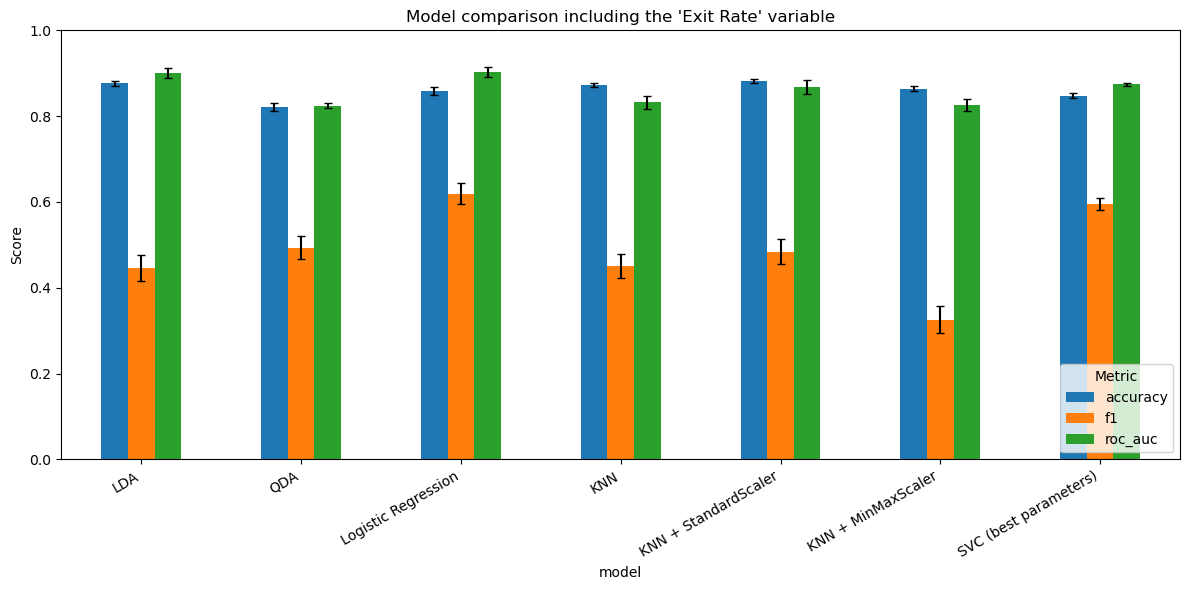

In [54]:
import matplotlib.pyplot as plt

results_plot = results.set_index('model')

# Colonne delle metriche (senza le colonne _std)
metric_cols = [c for c in results_plot.columns if not c.endswith('_std')]
std_cols = [c + '_std' for c in metric_cols]

means = results_plot[metric_cols]
stds = results_plot[std_cols]
stds.columns = metric_cols  # rinomino per allineare gli indici con means

ax = means.plot(
    kind='bar',
    figsize=(12, 6),
    yerr=stds,
    capsize=3
)
plt.ylabel("Score")
plt.title("Model comparison including the 'Exit Rate' variable")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', title='Metric')
plt.tight_layout()
plt.show()

### Recomputing Performance without ```ExitRates```

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_ite

,model,accuracy,accuracy_std,f1,f1_std,roc_auc,roc_auc_std
0,LDA,0.875540,0.004797,0.444602,0.024626,0.898145,0.012293
1,QDA,0.820932,0.011278,0.466035,0.023631,0.813521,0.005952
2,Logistic Regression,0.859645,0.009049,0.618749,0.023408,0.902426,0.010709
3,KNN,0.873270,0.004800,0.449785,0.027542,0.831787,0.014882
4,KNN + StandardScaler,0.882245,0.004938,0.490577,0.026196,0.867927,0.011579
5,KNN + MinMaxScaler,0.865484,0.006051,0.354157,0.027582,0.837852,0.013429
6,SVC (best parameters),0.851319,0.005876,0.606822,0.010000,0.872857,0.004465


Text(0, 0.5, 'Score')

Text(0.5, 1.0, "Model comparison not including the 'Exit Rate' variable")

(0.0, 1.0)

(array([0, 1, 2, 3, 4, 5, 6]),
 [Text(0, 0, 'LDA'),
  Text(1, 0, 'QDA'),
  Text(2, 0, 'Logistic Regression'),
  Text(3, 0, 'KNN'),
  Text(4, 0, 'KNN + StandardScaler'),
  Text(5, 0, 'KNN + MinMaxScaler'),
  Text(6, 0, 'SVC (best parameters)')])

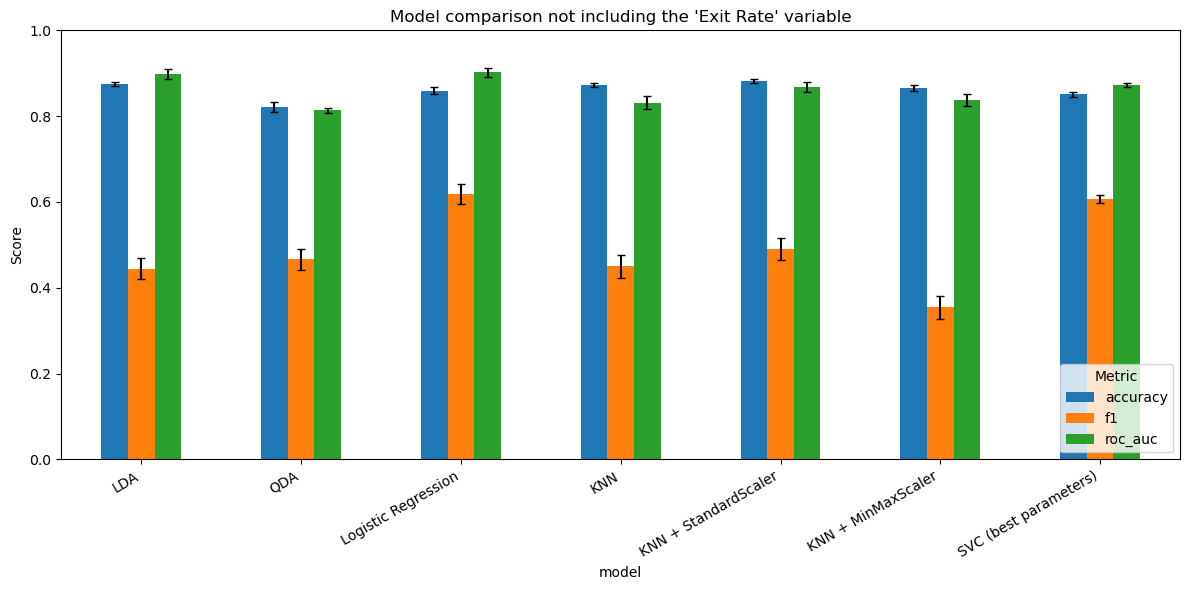

In [55]:
#recomputing the performance without the 'Exit Rate' feature in order to see if it adds something useful to the model: 

#redefinition of X_selected 
selected_feature_NOExitRates= ['Administrative','Informational','ProductRelated','ProductRelated_Duration','PageValues','month_sin','month_cos' 
                           ,'Region_9', 'TrafficType_2', 'TrafficType_3', 'TrafficType_8','TrafficType_10','TrafficType_11','TrafficType_13', 'TrafficType_20']

X_selected = train_data[selected_feature_NOExitRates]

# Define models

lda = LDA()
qda = QDA()

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")

knn = KNeighborsClassifier(n_neighbors=11)

knn_std = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=16))
])

knn_minmax = Pipeline([
    ('scaler', MinMaxScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=17))
])

SVC_best = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(
        kernel='rbf',
        C=10,
        gamma=0.1,
        class_weight='balanced'
    ))
])

models = OrderedDict([
    ('LDA', lda),
    ('QDA', qda),
    ('Logistic Regression', log_reg),
    ('KNN', knn),
    ('KNN + StandardScaler', knn_std),
    ('KNN + MinMaxScaler', knn_minmax),
    ('SVC (best parameters)', SVC_best)
])

# Compare models (CV only)

scoring = {
    'accuracy': 'accuracy',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results_list = []
for name, model in models.items():
    cv_res = cross_validate(
        model, X_selected, y,
        cv=5,
        scoring=scoring,
        n_jobs=-1
    )
    row = {'model': name}
    for metric in scoring:
        row[metric] = cv_res[f'test_{metric}'].mean()
        row[f'{metric}_std'] = cv_res[f'test_{metric}'].std()
    results_list.append(row)

results = pd.DataFrame(results_list)
results

#and now we print the same graph in order to compare the different models:

results_plot = results.set_index('model')

# Colonne delle metriche (senza le colonne _std)
metric_cols = [c for c in results_plot.columns if not c.endswith('_std')]
std_cols = [c + '_std' for c in metric_cols]

means = results_plot[metric_cols]
stds = results_plot[std_cols]
stds.columns = metric_cols  # rinomino per allineare gli indici con means

ax = means.plot(
    kind='bar',
    figsize=(12, 6),
    yerr=stds,
    capsize=3
)
plt.ylabel("Score")
plt.title("Model comparison not including the 'Exit Rate' variable")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right', title='Metric')
plt.tight_layout()
plt.show()

### Best Classifer: Logistic Regression

We obtain a little different in the results but at the end the best model is always the logistic regression (almost with the same value) so we would say that the Exit Rates do not make such difference in the model prediction in order to correctly classify the model.
We will stay with the first model that include the 'Exit Rate' variable and test on the test set to obtain a plausible test error:

In [56]:
X_selected = train_data[selected_features]

best_classifier = Pipeline([('scaler', StandardScaler()),
                      ('lasso', LogisticRegression(
                                solver="liblinear",   
                                max_iter=1000,
                                class_weight="balanced"))])

best_classifier.fit(X_selected, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

#### Best Classifier on Test Set

In [57]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
#now we can construct the confusion metrics and extract the test set error with a full report:
y_test = test_data['Revenue']
X_test = test_data[selected_features]

y_test_prediction = best_classifier.predict(X_test)

lr_results = {
    'Method': 'Logistic Regression (Supervised)',
    'accuracy': accuracy_score(y_test, y_test_prediction),
    'precision': precision_score(y_test, y_test_prediction),
    'recall': recall_score(y_test, y_test_prediction),
    'f1': f1_score(y_test, y_test_prediction),
    'roc_auc': roc_auc_score(y_test, y_test_prediction)
}
print(lr_results)

{'Method': 'Logistic Regression (Supervised)', 'accuracy': 0.8653471771576898, 'precision': 0.5375722543352601, 'recall': 0.7965738758029979, 'f1': 0.6419327006039689, 'roc_auc': np.float64(0.8371014694502561)}


Our best classifier performs better with our selected features obtained by FFS

Confusion Matrix:
[[2295  320]
 [  95  372]]
Matrix shape: (2, 2)

Accuracy: 0.8653
Misclassification rate: 0.1347
Sensitivity (recall): 0.7966
Precision: 0.5376
Specificity: 0.8776


Text(0.5, 1.0, 'Confusion Matrix')

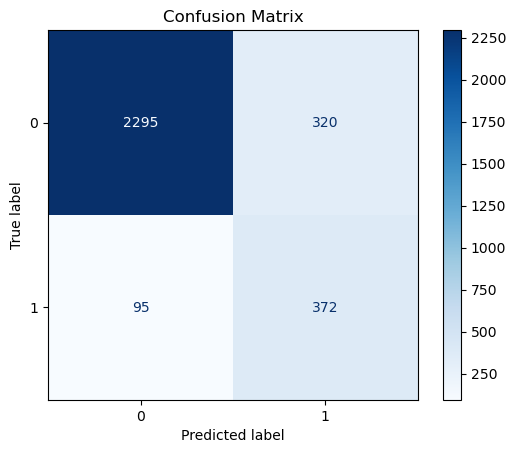

<Axes: >

Text(0.5, 1.0, 'Confusion Matrix (percentuali)')

Text(0.5, 23.52222222222222, 'Predicted label')

Text(50.722222222222214, 0.5, 'True label')

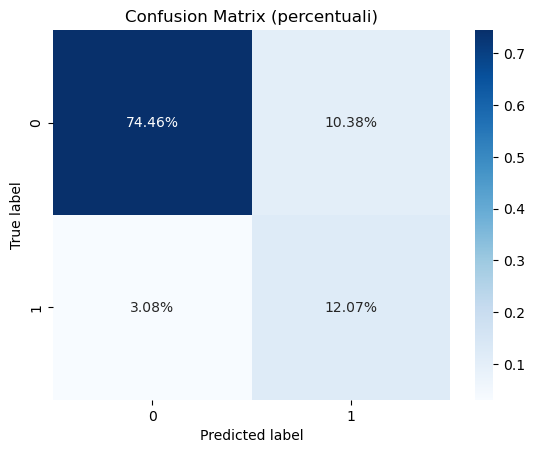

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'ROC Curve of Lasso Logistic Regression')

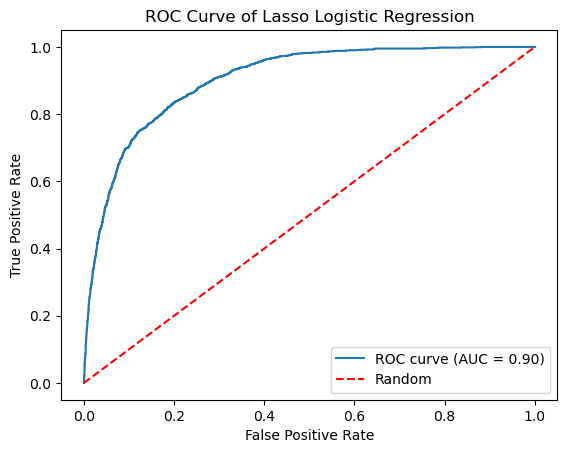

In [58]:
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, recall_score, precision_score, roc_curve, auc
)

import seaborn as sns
import numpy as np

# Compute confusion matrix
cm = confusion_matrix(
    y_test,
    y_test_prediction
)
print("Confusion Matrix:")
print(cm)
print("Matrix shape:", cm.shape)

#metrics calculation
accuracy = accuracy_score(y_test, y_test_prediction)
misclass = 1 - accuracy
sensitivity = recall_score(y_test, y_test_prediction)          
precision = precision_score(y_test, y_test_prediction)         

tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)                                   

print("\nAccuracy: {:.4f}".format(accuracy))
print("Misclassification rate: {:.4f}".format(misclass))
print("Sensitivity (recall): {:.4f}".format(sensitivity))
print("Precision: {:.4f}".format(precision))
print("Specificity: {:.4f}".format(specificity))

#plot
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

#heatmap
sns.heatmap(cm / np.sum(cm), annot=True, fmt='.2%', cmap='Blues')
plt.title("Confusion Matrix (percentuali)")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()


#plot ROC curve: 
# Probabilità predette (classe positiva = 1)
y_prob = best_classifier.predict_proba(X_selected)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y, y_prob)

# Compute AUC
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.plot(fpr, tpr, label='ROC curve (AUC = {:.2f})'.format(roc_auc))
plt.plot([0, 1], [0, 1], linestyle='--', color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve of Lasso Logistic Regression')
plt.legend(loc='lower right')
plt.show()

---
---
---

# Task 3 
_Repeat the analysis done at step 2 with clustering-based algorithms; compare the performance with respect to the best classification model_

I guess we have to predict ``Revenue`` but using clustering. 

## Dimensionality Reduction

In [59]:
numerical_cols = [
    'Administrative', 'Administrative_Duration', 'Informational',
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'month_sin', 'month_cos'
]

categorical_cols = [
    'Weekend', 'VisitorType_Other', 'VisitorType_Returning_Visitor',
    'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6',
    'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
    'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
    'Region_7', 'Region_8', 'Region_9',
    'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5',
    'TrafficType_6', 'TrafficType_7', 'TrafficType_8', 'TrafficType_9',
    'TrafficType_10', 'TrafficType_11', 'TrafficType_12', 'TrafficType_13',
    'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_17',
    'TrafficType_18', 'TrafficType_19', 'TrafficType_20',
    'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_4',
    'OperatingSystems_5', 'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8'
]
y = train_data['Revenue'].astype(int)  # target binario, solo per validazione esterna

## Numerical PCA

PCA()

<Figure size 800x500 with 0 Axes>

Text(0.5, 0, 'Number of Components')

Text(0, 0.5, 'Cumulative Explained Variance')

Text(0.5, 1.0, 'Cumulative Explained Variance by Number of Components')

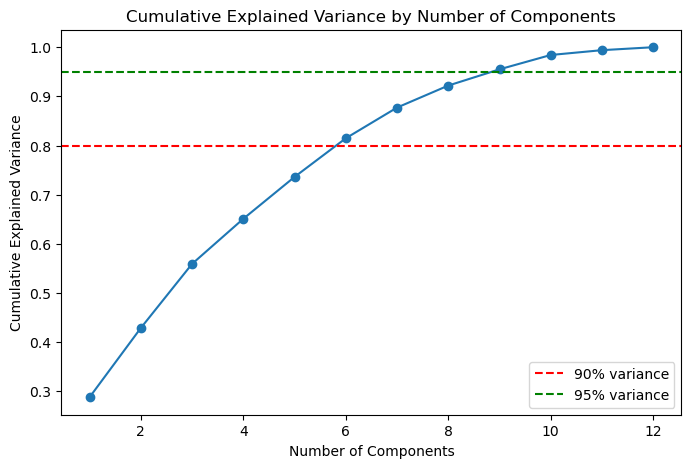

In [60]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import numpy as np

X_NUM = train_data[numerical_cols]
# Always scale before PCA — it's sensitive to feature scale
scaler = StandardScaler()
X_train_scaled_NUM = scaler.fit_transform(X_NUM)

# Fit PCA with no component limit, just to inspect variance
pca_NUM = PCA()
pca_NUM.fit(X_train_scaled_NUM)

cumulative_var = np.cumsum(pca_NUM.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_var)+1), cumulative_var, marker='o')
plt.axhline(y=0.80, color='r', linestyle='--', label='90% variance')
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.title('Cumulative Explained Variance by Number of Components')
plt.show()

In [61]:
# 1. Initialize PCA with your chosen 6 components
pca_6 = PCA(n_components=6, random_state=42)

# 2. Transform your scaled numerical data into the 6 components
# This creates a NumPy array of shape (number of rows, 6)
X_NUMpca_array = pca_6.fit_transform(X_train_scaled_NUM)

# 3. Convert it into a clean Pandas DataFrame with explicit column names
pc_columns = [f"PC{i+1}" for i in range(6)]
X_pca_NUMfinal = pd.DataFrame(X_NUMpca_array, columns=pc_columns)


## UMAP

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


<Figure size 1000x700 with 0 Axes>

Text(0.5, 0, 'UMAP 1')

Text(0, 0.5, 'UMAP 2')

Text(0.5, 1.0, 'UMAP PCs=6')

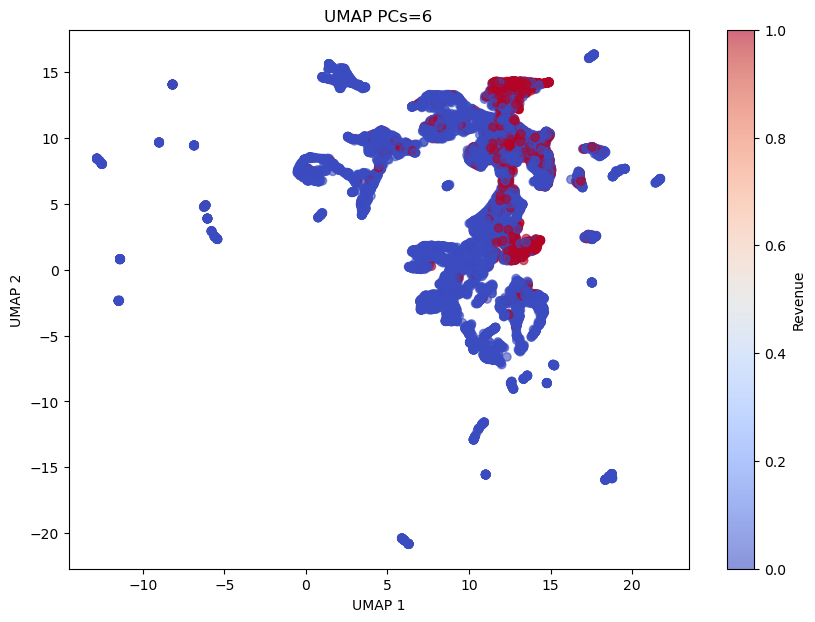

In [62]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_NUMpca_array)

# Plot
plt.figure(figsize=(10, 7))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.colorbar(label='Revenue')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.title('UMAP PCs=6')
plt.show()

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Text(0.5, 0, 'UMAP 1')

Text(0.5, 0.5, 'UMAP 2')

Text(0.5, 0, 'UMAP 3')

Text(0.5, 0.92, 'UMAP 3D PCs=6')

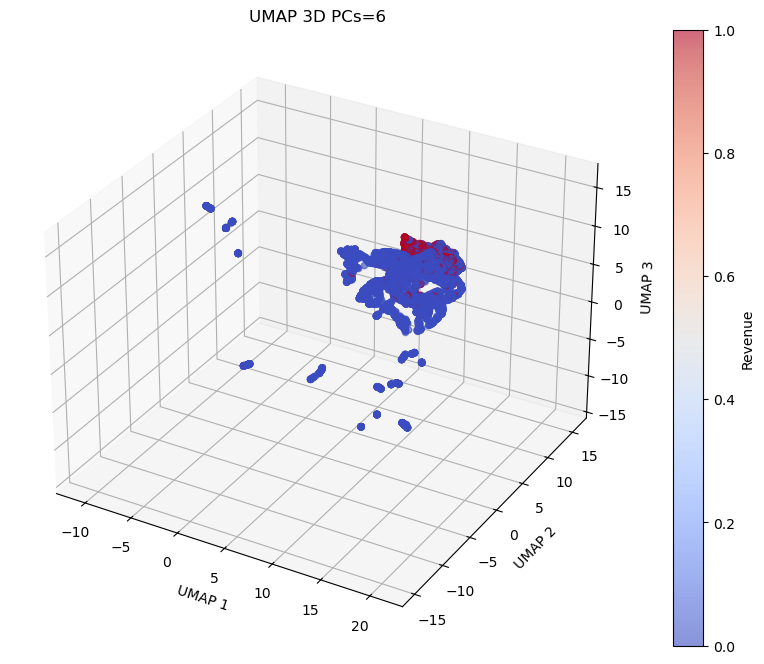

In [63]:
import umap
from mpl_toolkits.mplot3d import Axes3D

# Step 2: UMAP riduce a 3 componenti
reducer = umap.UMAP(n_components=3, random_state=42)
X_umap3d = reducer.fit_transform(X_NUMpca_array)

# Step 3: scatter plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_umap3d[:, 0], X_umap3d[:, 1], X_umap3d[:, 2],
                 c=y, cmap='coolwarm', alpha=0.6)

ax.set_xlabel('UMAP 1')
ax.set_ylabel('UMAP 2')
ax.set_zlabel('UMAP 3')
ax.set_title('UMAP 3D PCs=6')

fig.colorbar(sc, ax=ax, label='Revenue')
plt.show()

## t-SNE

<Figure size 1000x700 with 0 Axes>

Text(0.5, 0, 't-SNE 1')

Text(0, 0.5, 't-SNE 2')

Text(0.5, 1.0, 't-SNE 2D PCs=6')

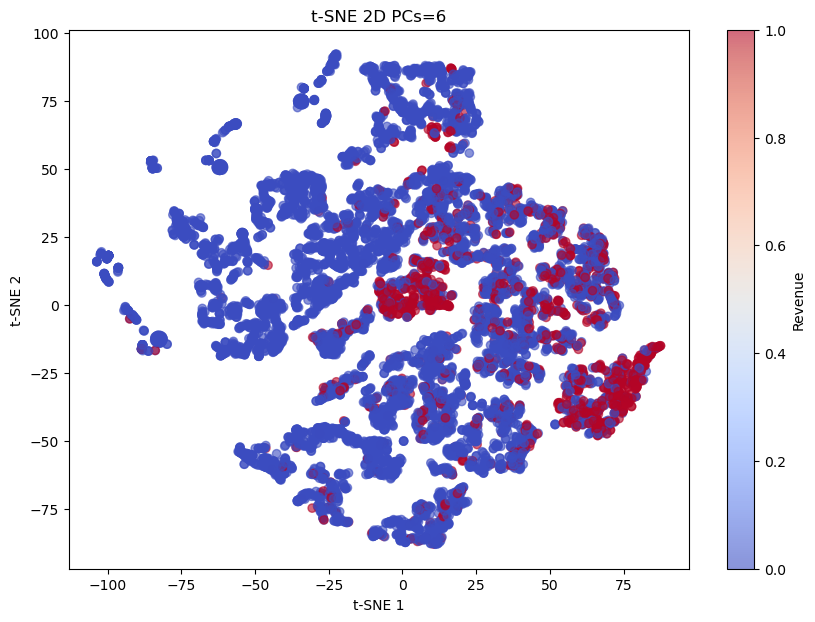

In [64]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne2d = tsne.fit_transform(X_NUMpca_array)

# Plot
plt.figure(figsize=(10, 7))
sc = plt.scatter(X_tsne2d[:, 0], X_tsne2d[:, 1], c=y, cmap='coolwarm', alpha=0.6)
plt.colorbar(sc, label='Revenue')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE 2D PCs=6')
plt.show()

Text(0.5, 0, 't-SNE 1')

Text(0.5, 0.5, 't-SNE 2')

Text(0.5, 0, 't-SNE 3')

Text(0.5, 0.92, 't-SNE 3D su PCs=6')

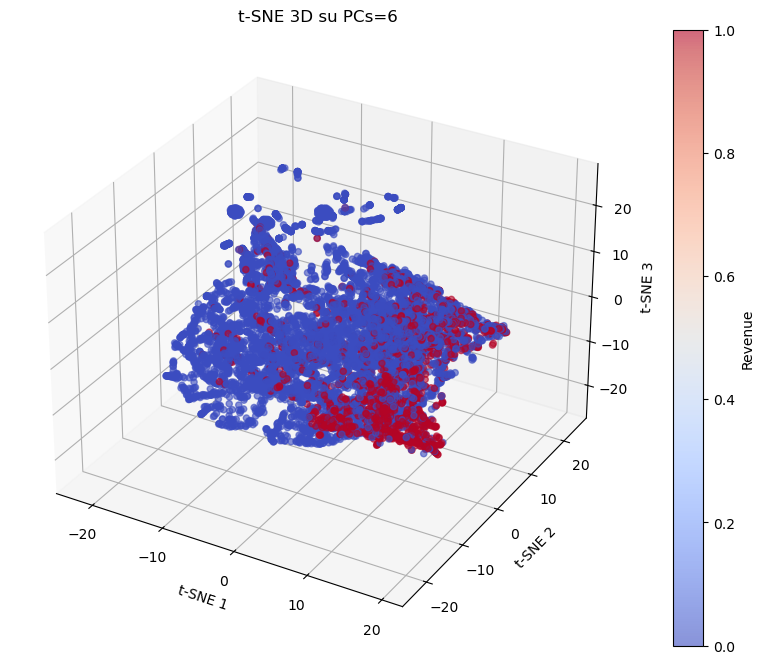

In [65]:
from sklearn.manifold import TSNE
from mpl_toolkits.mplot3d import Axes3D

tsne = TSNE(n_components=3, random_state=42, perplexity=30)
X_tsne3d = tsne.fit_transform(X_NUMpca_array)

# Step 3: scatter plot 3D
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(X_tsne3d[:, 0], X_tsne3d[:, 1], X_tsne3d[:, 2],
                 c=y, cmap='coolwarm', alpha=0.6)

ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_zlabel('t-SNE 3')
ax.set_title('t-SNE 3D su PCs=6')

fig.colorbar(sc, ax=ax, label='Revenue')
plt.show()

---
---

# Clustering

In [66]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler

# df = il tuo dataframe originale, già con Revenue come colonna target (non nel clustering)

numerical_cols = [
    'Administrative', 'Administrative_Duration', 'Informational',
    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay',
    'month_sin', 'month_cos'
]

categorical_cols = [
    'Weekend', 'VisitorType_Other', 'VisitorType_Returning_Visitor',
    'Browser_2', 'Browser_3', 'Browser_4', 'Browser_5', 'Browser_6',
    'Browser_7', 'Browser_8', 'Browser_10', 'Browser_11', 'Browser_12', 'Browser_13',
    'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
    'Region_7', 'Region_8', 'Region_9',
    'TrafficType_2', 'TrafficType_3', 'TrafficType_4', 'TrafficType_5',
    'TrafficType_6', 'TrafficType_7', 'TrafficType_8', 'TrafficType_9',
    'TrafficType_10', 'TrafficType_11', 'TrafficType_12', 'TrafficType_13',
    'TrafficType_14', 'TrafficType_15', 'TrafficType_16', 'TrafficType_17',
    'TrafficType_18', 'TrafficType_19', 'TrafficType_20',
    'OperatingSystems_2', 'OperatingSystems_3', 'OperatingSystems_4',
    'OperatingSystems_5', 'OperatingSystems_6', 'OperatingSystems_7', 'OperatingSystems_8'
]

y = train_data['Revenue'].astype(int)  # target binario, solo per validazione esterna


### Metrics

In [67]:
# SUPER UNIONE DELLE METRICHE
import numpy as np
import pandas as pd
from sklearn.metrics import (
    jaccard_score, adjusted_rand_score, normalized_mutual_info_score,
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)


def compute_recall(cluster_labels, true_labels, cluster_index, class_label):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]
    class_indices = np.where(true_labels == class_label)[0]
    nkj = len(np.intersect1d(cluster_indices, class_indices))
    nj = len(class_indices)
    return nkj / nj if nj > 0 else 0.0


def compute_precision(cluster_labels, true_labels, cluster_index, class_label):
    cluster_indices = np.where(cluster_labels == cluster_index)[0]
    class_indices = np.where(true_labels == class_label)[0]
    nkj = len(np.intersect1d(cluster_indices, class_indices))
    nk = len(cluster_indices)
    return nkj / nk if nk > 0 else 0.0


def evaluate_clustering(pred_labels, y, name="Model", X=None):
    """
    Evaluates a binary (2-cluster) clustering against a binary target.
    Aligns cluster labels with class labels to avoid arbitrary 0/1 swap penalties.
    If X is provided, also computes internal clustering-quality metrics.
    """
    y = np.asarray(y)
    pred_labels = np.asarray(pred_labels)

    n_cluster_0 = int(np.sum(pred_labels == 0))
    n_cluster_1 = int(np.sum(pred_labels == 1))

    # --- Align cluster labels with y (pick whichever mapping maximizes accuracy) ---
    acc_direct = np.mean(pred_labels == y)
    acc_swapped = np.mean((1 - pred_labels) == y)
    swapped = acc_swapped > acc_direct
    pred_aligned = (1 - pred_labels) if swapped else pred_labels
    acc = max(acc_direct, acc_swapped)

    # --- Per-cluster recall / precision (external, uses true labels) ---
    recall_0_0 = compute_recall(pred_aligned, y, 0, 0)
    recall_0_1 = compute_recall(pred_aligned, y, 0, 1)
    recall_1_0 = compute_recall(pred_aligned, y, 1, 0)
    recall_1_1 = compute_recall(pred_aligned, y, 1, 1)

    precision_0_0 = compute_precision(pred_aligned, y, 0, 0)
    precision_0_1 = compute_precision(pred_aligned, y, 0, 1)
    precision_1_0 = compute_precision(pred_aligned, y, 1, 0)
    precision_1_1 = compute_precision(pred_aligned, y, 1, 1)

    purity_0 = max(precision_0_0, precision_0_1)
    purity_1 = max(precision_1_1, precision_1_0)

    # --- External metrics (agreement with true labels) ---
    jaccard = jaccard_score(y, pred_aligned)
    ari = adjusted_rand_score(y, pred_labels)          # ARI/NMI are label-invariant, no need for alignment
    nmi = normalized_mutual_info_score(y, pred_labels)

    # --- Internal metrics (cluster quality, no labels needed) ---
    if X is not None:
        silhouette = silhouette_score(X, pred_labels)
        davies_bouldin = davies_bouldin_score(X, pred_labels)
        calinski_harabasz = calinski_harabasz_score(X, pred_labels)
    else:
        silhouette = davies_bouldin = calinski_harabasz = np.nan

    print(f"--- {name} ---")
    print(f"Cluster sizes: cluster 0 = {n_cluster_0}, cluster 1 = {n_cluster_1}")
    print(f"Accuracy (aligned): {acc:.4f}  {'(labels swapped)' if swapped else ''}")
    print(f"Purity: cluster 0 = {purity_0:.4f}, cluster 1 = {purity_1:.4f}")
    print(f"Jaccard: {jaccard:.4f} | ARI: {ari:.4f} | NMI: {nmi:.4f}")
    if X is not None:
        print(f"Silhouette: {silhouette:.4f} | Davies-Bouldin: {davies_bouldin:.4f} | Calinski-Harabasz: {calinski_harabasz:.2f}")
    print()

    return {
        'Method': name,
        'n_cluster_0': n_cluster_0,
        'n_cluster_1': n_cluster_1,
        'accuracy': acc,
        'recall_0_0': recall_0_0, 'recall_0_1': recall_0_1,
        'recall_1_0': recall_1_0, 'recall_1_1': recall_1_1,
        'precision_0_0': precision_0_0, 'precision_0_1': precision_0_1,
        'precision_1_0': precision_1_0, 'precision_1_1': precision_1_1,
        'purity_0': purity_0, 'purity_1': purity_1,
        'jaccard': jaccard,
        'ari': ari,
        'nmi': nmi,
        'silhouette': silhouette,
        'davies_bouldin': davies_bouldin,
        'calinski_harabasz': calinski_harabasz,
    }

## K-means

### All numerical

In [68]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Standardizzazione delle feature numeriche
scaler = StandardScaler()
X_numerical_scaled = scaler.fit_transform(train_data[numerical_cols])

# K-means su feature numeriche standardizzate
kmeans_NUM = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init="auto")
kmeans_NUM.fit(X_numerical_scaled)
pred_labels_NUM = kmeans_NUM.labels_

results_kmeans_NUM = evaluate_clustering(pred_labels_NUM, y, name="KMeans (Numerical, Scaled)", X=X_numerical_scaled)

KMeans(n_clusters=2, random_state=42)

--- KMeans (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4388, cluster 1 = 4860
Accuracy (aligned): 0.5630  
Purity: cluster 0 = 0.9291, cluster 1 = 0.7675
Jaccard: 0.2185 | ARI: 0.0146 | NMI: 0.0467
Silhouette: 0.1734 | Davies-Bouldin: 2.0595 | Calinski-Harabasz: 1571.79



### Numerical + PCA

No need to scale since X_num already scaled. se facciamo pca senza scegliere i componenti è come se avessimo tutte le features ma lungo tutti i PCs. 

In [69]:
# 1. Initialize K-Means 
# We'll use 2 clusters since that was in your original code
kmeans_NUM_PCA = KMeans(n_clusters=2, init='k-means++', random_state=42, n_init="auto")

# 2. Fit the model AND get the cluster labels all in one step
# We pass our 6-component DataFrame here
pred_labels_NUM_PCA_kmeans = kmeans_NUM_PCA.fit_predict(X_pca_NUMfinal)

results_kmeans_NUM_PCA = evaluate_clustering(
    pred_labels_NUM_PCA_kmeans, 
    y, 
    name="KMeans (6 PCA Components)", X=X_pca_NUMfinal
)
print(results_kmeans_NUM_PCA)

--- KMeans (6 PCA Components) ---
Cluster sizes: cluster 0 = 4290, cluster 1 = 4958
Accuracy (aligned): 0.5604  
Purity: cluster 0 = 0.9361, cluster 1 = 0.7646
Jaccard: 0.2231 | ARI: 0.0121 | NMI: 0.0533
Silhouette: 0.2045 | Davies-Bouldin: 1.7726 | Calinski-Harabasz: 1960.84

{'Method': 'KMeans (6 PCA Components)', 'n_cluster_0': 4290, 'n_cluster_1': 4958, 'accuracy': np.float64(0.5604455017301038), 'recall_0_0': 0.5144101447418983, 'recall_0_1': 0.19014573213046496, 'recall_1_0': 0.4855898552581017, 'recall_1_1': 0.8098542678695351, 'precision_0_0': 0.9361305361305361, 'precision_0_1': 0.06386946386946386, 'precision_1_0': 0.7646228317870108, 'precision_1_1': 0.2353771682129891, 'purity_0': 0.9361305361305361, 'purity_1': 0.7646228317870108, 'jaccard': np.float64(0.22305045871559634), 'ari': 0.012116408093444088, 'nmi': np.float64(0.05332801040872056), 'silhouette': np.float64(0.2045070502646537), 'davies_bouldin': np.float64(1.772644338255775), 'calinski_harabasz': np.float64(1960.8

## Categorical distance matrix

In [70]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import OrdinalEncoder
from scipy.spatial.distance import pdist, squareform

# Encode categoricals as integer codes (needed for Hamming distance computation)
encoder = OrdinalEncoder()
X_categorical_encoded = encoder.fit_transform(train_data[categorical_cols])

# Precompute the Hamming distance matrix
cat_dist_matrix = squareform(pdist(X_categorical_encoded, metric='hamming'))


## K-Medoids

### All numerical

In [71]:
""" from skitlearn_extra import Kmedoids

kmedoids_NUM = KMedoids(n_clusters=2, metric='euclidean', init='k-medoids++', random_state=42)
kmedoids_NUM.fit(X_numerical_scaled)
pred_labels_NUM_medoids = kmedoids_NUM.labels_

results_kmedoids_NUM = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)") """

' from skitlearn_extra import Kmedoids\n\nkmedoids_NUM = KMedoids(n_clusters=2, metric=\'euclidean\', init=\'k-medoids++\', random_state=42)\nkmedoids_NUM.fit(X_numerical_scaled)\npred_labels_NUM_medoids = kmedoids_NUM.labels_\n\nresults_kmedoids_NUM = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)") '

In [72]:
import kmedoids
import numpy as np
from sklearn.metrics import pairwise_distances

# 1. Calculate the distance matrix first
# KMedoids in this package requires a distance matrix input
dist_matrix = pairwise_distances(X_numerical_scaled, metric='euclidean')

# 2. Fit the model using FasterPAM
# FasterPAM is the recommended, efficient implementation
result = kmedoids.fasterpam(dist_matrix, 2)

pred_labels_NUM_medoids = result.labels

# 4. Evaluate using your existing function
results_kmedoids_NUM = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)", X=X_numerical_scaled)

--- KMedoids (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4631, cluster 1 = 4617
Accuracy (aligned): 0.5500  
Purity: cluster 0 = 0.8935, cluster 1 = 0.7947
Jaccard: 0.1855 | ARI: 0.0099 | NMI: 0.0167
Silhouette: 0.1918 | Davies-Bouldin: 2.1514 | Calinski-Harabasz: 1365.51



### Categorical

In [73]:
""" kmedoids_CAT = KMedoids(n_clusters=2, metric='hamming', init='k-medoids++', random_state=42)
kmedoids_CAT.fit(X_categorical_encoded)
pred_labels_CAT_medoids = kmedoids_NUM.labels_

results_kmedoids_CAT = evaluate_clustering(pred_labels_CAT_medoids, y, name="KMedoids (Numerical, Scaled)") """

' kmedoids_CAT = KMedoids(n_clusters=2, metric=\'hamming\', init=\'k-medoids++\', random_state=42)\nkmedoids_CAT.fit(X_categorical_encoded)\npred_labels_CAT_medoids = kmedoids_NUM.labels_\n\nresults_kmedoids_CAT = evaluate_clustering(pred_labels_CAT_medoids, y, name="KMedoids (Numerical, Scaled)") '

In [74]:
# 1. Calculate the distance matrix first
# KMedoids in this package requires a distance matrix input
dist_matrix = pairwise_distances(X_categorical_encoded, metric='euclidean')

# 2. Fit the model using FasterPAM
# FasterPAM is the recommended, efficient implementation
result = kmedoids.fasterpam(dist_matrix, 2)

pred_labels_CAT_medoids = result.labels

# 4. Evaluate using your existing function
results_kmedoids_CAT = evaluate_clustering(pred_labels_CAT_medoids, y, name="KMedoids (Numerical, Scaled)", X=X_categorical_encoded)

--- KMedoids (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 3049, cluster 1 = 6199
Accuracy (aligned): 0.6241  (labels swapped)
Purity: cluster 0 = 0.8493, cluster 1 = 0.8337
Jaccard: 0.1273 | ARI: 0.0070 | NMI: 0.0004
Silhouette: 0.1158 | Davies-Bouldin: 2.8859 | Calinski-Harabasz: 937.01



### Numerical + PCA

In [75]:
""" kmedoids_NUM = KMedoids(n_clusters=2, metric='euclidean', init='k-medoids++', random_state=42)
kmedoids_NUM.fit(X_pca_NUMfinal)
pred_labels_NUM_medoids = kmedoids_NUM.labels_

results_kmedoids_NUM_PCA = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)") """

' kmedoids_NUM = KMedoids(n_clusters=2, metric=\'euclidean\', init=\'k-medoids++\', random_state=42)\nkmedoids_NUM.fit(X_pca_NUMfinal)\npred_labels_NUM_medoids = kmedoids_NUM.labels_\n\nresults_kmedoids_NUM_PCA = evaluate_clustering(pred_labels_NUM_medoids, y, name="KMedoids (Numerical, Scaled)") '

In [76]:
# 1. Calculate the distance matrix first
# KMedoids in this package requires a distance matrix input
dist_matrix = pairwise_distances(X_pca_NUMfinal, metric='euclidean')

# 2. Fit the model using FasterPAM
# FasterPAM is the recommended, efficient implementation
result = kmedoids.fasterpam(dist_matrix, 2)

pred_labels_NUM_PCAmedoids = result.labels

# 4. Evaluate using your existing function
results_kmedoids_NUM_PCA = evaluate_clustering(pred_labels_NUM_PCAmedoids, y, name="KMedoids (Numerical, Scaled)", X=X_pca_NUMfinal)

--- KMedoids (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 4525, cluster 1 = 4723
Accuracy (aligned): 0.5433  
Purity: cluster 0 = 0.8959, cluster 1 = 0.7946
Jaccard: 0.1868 | ARI: 0.0072 | NMI: 0.0177
Silhouette: 0.2269 | Davies-Bouldin: 1.8792 | Calinski-Harabasz: 1646.59



## Hierarchical

Ww chose as metric 'complete' since 'ward' tends to create compact and evenly sized round clusters. Complete linkage merges based on the maximum distance.

### All numerical

In [77]:
from sklearn.cluster import AgglomerativeClustering
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')
pred_labels_NUM = hierarchical_cluster.fit_predict(X_NUM)

results_hierarchical_NUM = evaluate_clustering(pred_labels_NUM, y, name="KMeans (Numerical, Scaled)", X=X_NUM)

--- KMeans (Numerical, Scaled) ---
Cluster sizes: cluster 0 = 29, cluster 1 = 9219
Accuracy (aligned): 0.8436  (labels swapped)
Purity: cluster 0 = 0.8450, cluster 1 = 0.5862
Jaccard: 0.0082 | ARI: 0.0083 | NMI: 0.0026
Silhouette: 0.8939 | Davies-Bouldin: 0.2841 | Calinski-Harabasz: 2635.77



In [98]:
from scipy.cluster.hierarchy import dendrogram, linkage

distance_threshold=None#270

def plot_dendrogram(Z=None, model=None, X=None, **kwargs):
    annotate_above = kwargs.pop('annotate_above', 0)

    # Reconstruct the linakge matrix if the standard model API was used
    if Z is None:
        if hasattr(model, 'distances_') and model.distances_ is not None:
            # create the counts of samples under each node
            counts = np.zeros(model.children_.shape[0])
            n_samples = len(model.labels_)
            for i, merge in enumerate(model.children_):
                current_count = 0
                for child_idx in merge:
                    if child_idx < n_samples:
                        current_count += 1  # leaf node
                    else:
                        current_count += counts[child_idx - n_samples]
                counts[i] = current_count

            Z = np.column_stack([model.children_, model.distances_,
                                              counts]).astype(float)
        else:
            Z = linkage(X, method=model.linkage, metric=model.metric)
    
    if 'n_clusters' in kwargs:
        n_clusters = kwargs.pop('n_clusters')
        # Set the cut point just above the last but 'n_clusters' merge
        kwargs['color_threshold'] = Z[-n_clusters, 2] + 1e-6
    
    fig = plt.figure(figsize=(20,10))
    ax = fig.add_subplot(111)
    # Plot the corresponding dendrogram
    ddata = dendrogram(Z, ax=ax, **kwargs) 
    
    # Annotate nodes in the dendrogram
    for i, d, c in zip(ddata['icoord'], ddata['dcoord'], ddata['color_list']):
        x = 0.5 * sum(i[1:3])
        y = d[1]
        nid = np.where(Z[:,2] == y)[0][0]
        if y > annotate_above:
            plt.plot(x, y, 'o', c=c)
            plt.annotate(str(nid-Z.shape[0]), (x, y), xytext=(0, -5),
                         textcoords='offset points',
                         va='top', ha='center')
    if kwargs['color_threshold']:
        plt.axhline(y=kwargs['color_threshold'], c='k')
    
    return fig, ax

(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

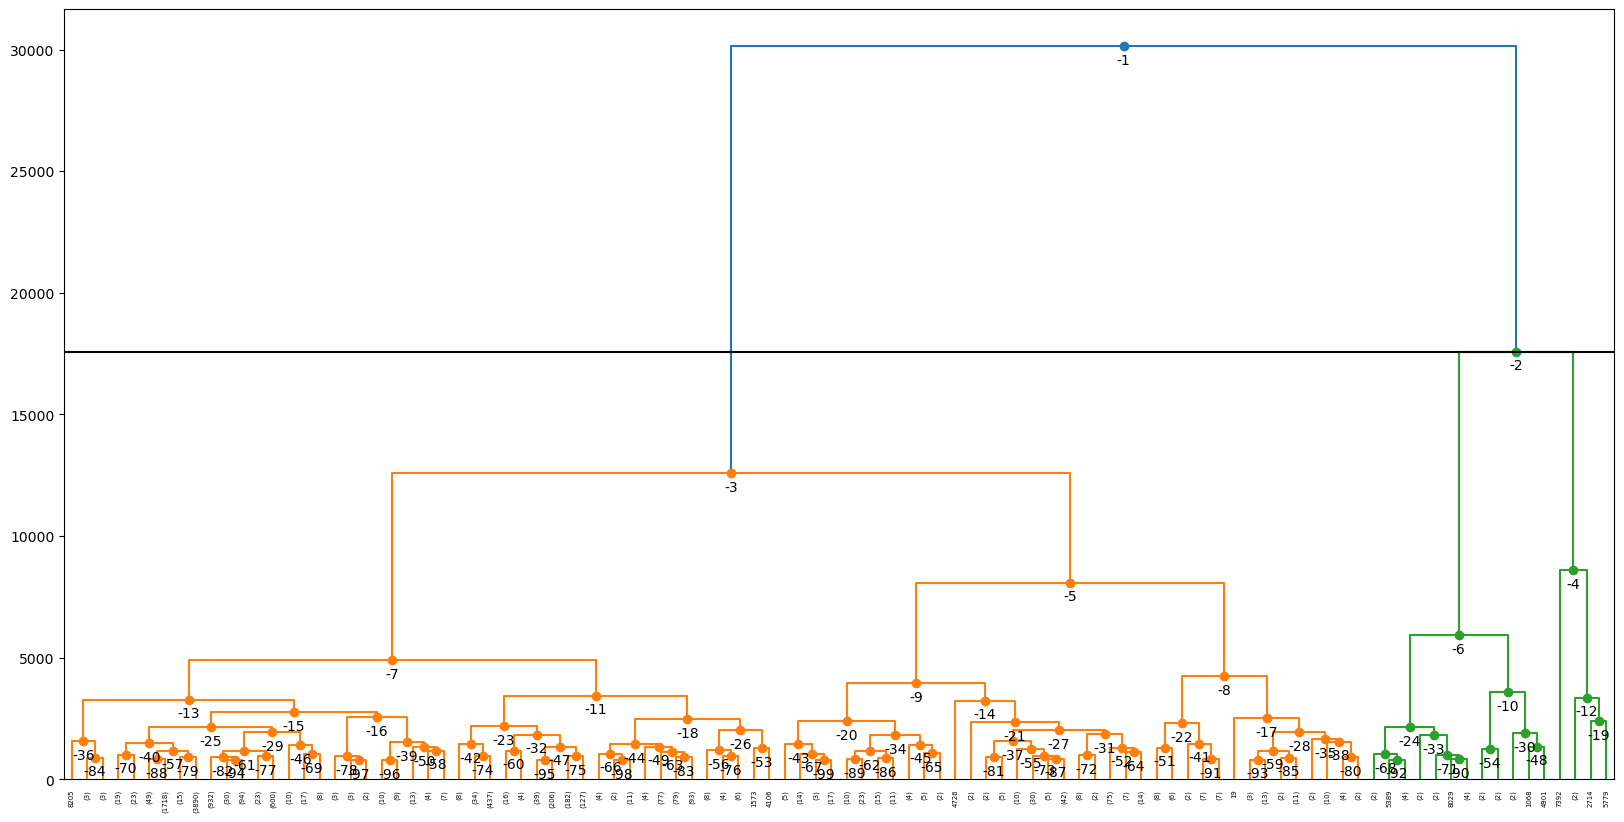

In [99]:

plot_dendrogram(model=hierarchical_cluster, X=X_NUM, truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

### Categorical

In [81]:

agg_CAT = AgglomerativeClustering(n_clusters=2, metric='hamming', linkage='complete')
pred_labels_CAT_agg = agg_CAT.fit_predict(cat_dist_matrix)

results_hierarchical_CAT = evaluate_clustering(pred_labels_CAT_agg, y, name="Agglomerative (Categorical, Hamming)", X=X_categorical_encoded)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_agglomerative.py:588: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  out = hierarchy.linkage(X, method=linkage, metric=affinity)


--- Agglomerative (Categorical, Hamming) ---
Cluster sizes: cluster 0 = 5838, cluster 1 = 3410
Accuracy (aligned): 0.5870  
Purity: cluster 0 = 0.8416, cluster 1 = 0.8487
Jaccard: 0.1190 | ARI: -0.0025 | NMI: 0.0001
Silhouette: -0.0012 | Davies-Bouldin: 8.4511 | Calinski-Harabasz: 111.29



/var/folders/wq/_525yx4972n7684bqsmf3gyr0000gn/T/ipykernel_10329/3277874667.py:26: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(X, method=model.linkage, metric=model.metric)


(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

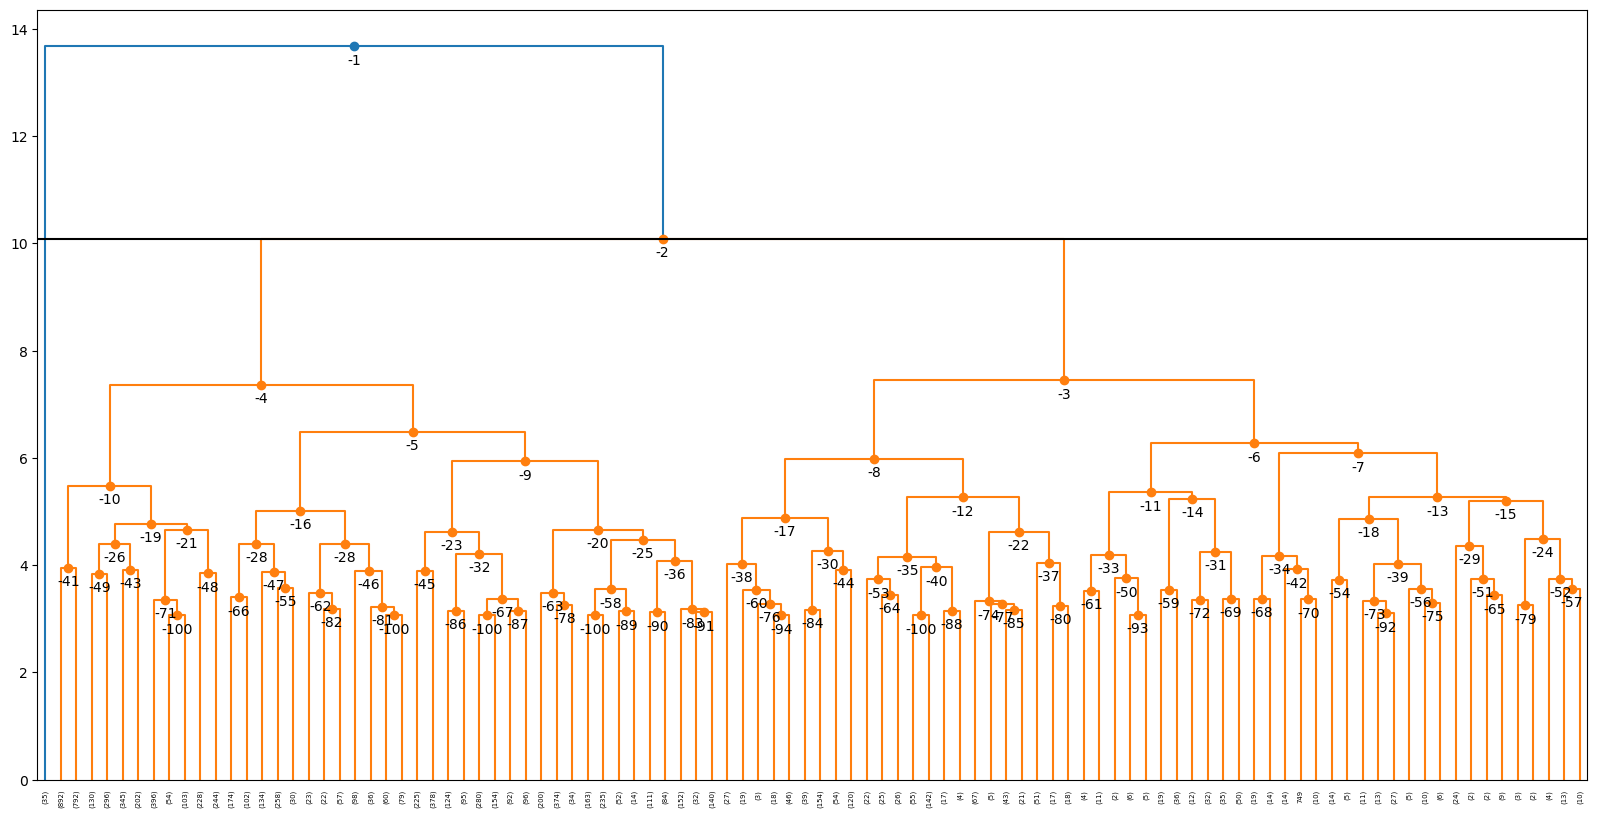

In [100]:
plot_dendrogram(model=hierarchical_cluster, X=cat_dist_matrix, truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

### NUM+PCA

In [83]:
hierarchical_cluster = AgglomerativeClustering(n_clusters=2, metric='euclidean', linkage='complete')
pred_labels_NUM_PCA_hierchical = hierarchical_cluster.fit_predict(X_pca_NUMfinal)

results_hierarchical_NUM_PCA = evaluate_clustering(pred_labels_NUM_PCA_hierchical, y, name="KMeans (Numerical, PCA)", X=X_pca_NUMfinal)

--- KMeans (Numerical, PCA) ---
Cluster sizes: cluster 0 = 9199, cluster 1 = 49
Accuracy (aligned): 0.8428  
Purity: cluster 0 = 0.8453, cluster 1 = 0.6327
Jaccard: 0.0122 | ARI: 0.0114 | NMI: 0.0030
Silhouette: 0.6739 | Davies-Bouldin: 0.6241 | Calinski-Harabasz: 605.57



(<Figure size 2000x1000 with 1 Axes>, <Axes: >)

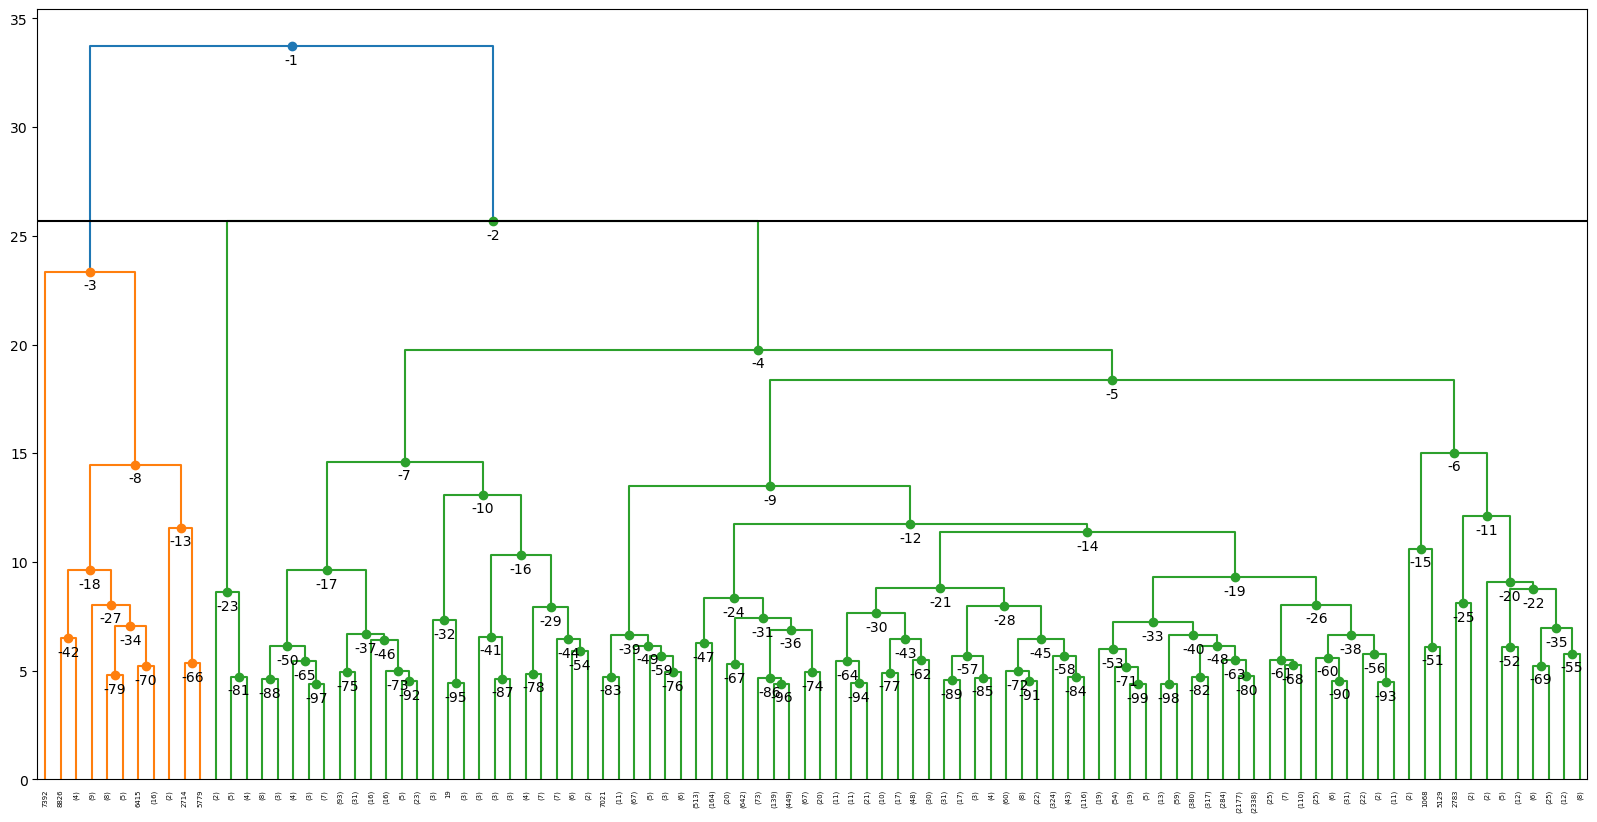

In [101]:
plot_dendrogram(model=hierarchical_cluster, X=X_NUMpca_array, truncate_mode='lastp', p=100, 
                n_clusters=2, 
                color_threshold=distance_threshold)

plt.show()

---

# FINAL CLUSTERING RESULTS

In [85]:
results_named = {
    "KMeans (Numerical)": results_kmeans_NUM,
    "KMeans (Numerical+PCA)": results_kmeans_NUM_PCA,
    "Hierchical (Numerical)": results_hierarchical_NUM,
    "Hierchical (Numerical+PCA)": results_hierarchical_NUM_PCA,
    "Hierchical (Categorical)": results_hierarchical_CAT,
    "Kmedoids (Numerical)": results_kmedoids_NUM,
    "Kmedoids (Numerical+PCA)": results_kmedoids_NUM_PCA,
    "Kmedoids (Categorical)": results_kmedoids_CAT,
}

all_results_df = pd.DataFrame(results_named).T
""" all_results_df.index.name = "Method"
all_results_df.reset_index(inplace=True) """

all_results_df

' all_results_df.index.name = "Method"\nall_results_df.reset_index(inplace=True) '

,Method,n_cluster_0,n_cluster_1,accuracy,recall_0_0,recall_0_1,recall_1_0,recall_1_1,precision_0_0,precision_0_1,precision_1_0,precision_1_1,purity_0,purity_1,jaccard,ari,nmi,silhouette,davies_bouldin,calinski_harabasz
KMeans (Numerical),"KMeans (Numerical, Scaled)",4388,4860,0.563041,0.522224,0.215822,0.477776,0.784178,0.929125,0.070875,0.76749,0.23251,0.929125,0.76749,0.218526,0.014624,0.046715,0.173399,2.059532,1571.790102
KMeans (Numerical+PCA),KMeans (6 PCA Components),4290,4958,0.560446,0.51441,0.190146,0.48559,0.809854,0.936131,0.063869,0.764623,0.235377,0.936131,0.764623,0.22305,0.012116,0.053328,0.204507,1.772644,1960.838246
Hierchical (Numerical),"KMeans (Numerical, Scaled)",29,9219,0.843642,0.997822,0.991672,0.002178,0.008328,0.844994,0.155006,0.586207,0.413793,0.844994,0.586207,0.00823,0.008338,0.002641,0.893881,0.284124,2635.773384
Hierchical (Numerical+PCA),"KMeans (Numerical, PCA)",9199,49,0.842777,0.996029,0.987509,0.003971,0.012491,0.845309,0.154691,0.632653,0.367347,0.845309,0.632653,0.012228,0.011425,0.003037,0.673854,0.624121,605.570399
Hierchical (Categorical),"Agglomerative (Categorical, Hamming)",5838,3410,0.587046,0.629307,0.641915,0.370693,0.358085,0.841555,0.158445,0.84868,0.15132,0.841555,0.84868,0.119031,-0.002488,0.000083,-0.001213,8.451076,111.291463
Kmedoids (Numerical),"KMedoids (Numerical, Scaled)",4631,4617,0.549957,0.530037,0.342124,0.469963,0.657876,0.893544,0.106456,0.794672,0.205328,0.893544,0.794672,0.185519,0.009925,0.016744,0.191777,2.151352,1365.511919
Kmedoids (Numerical+PCA),"KMedoids (Numerical, Scaled)",4525,4723,0.543253,0.519278,0.326856,0.480722,0.673144,0.895912,0.104088,0.794622,0.205378,0.895912,0.794622,0.186754,0.007211,0.017657,0.226868,1.879216,1646.586312
Kmedoids (Categorical),"KMedoids (Numerical, Scaled)",3049,6199,0.624135,0.674395,0.648161,0.325605,0.351839,0.849331,0.150669,0.833716,0.166284,0.849331,0.833716,0.127291,0.006998,0.000381,0.11579,2.88585,937.00613


In [86]:
# Keep only internal + external columns
internal_cols = ['silhouette', 'davies_bouldin', 'calinski_harabasz']
external_cols = ['accuracy', 'jaccard', 'ari', 'nmi']

metric_df = all_results_df[internal_cols + external_cols]
metric_df



,silhouette,davies_bouldin,calinski_harabasz,accuracy,jaccard,ari,nmi
KMeans (Numerical),0.173399,2.059532,1571.790102,0.563041,0.218526,0.014624,0.046715
KMeans (Numerical+PCA),0.204507,1.772644,1960.838246,0.560446,0.22305,0.012116,0.053328
Hierchical (Numerical),0.893881,0.284124,2635.773384,0.843642,0.00823,0.008338,0.002641
Hierchical (Numerical+PCA),0.673854,0.624121,605.570399,0.842777,0.012228,0.011425,0.003037
Hierchical (Categorical),-0.001213,8.451076,111.291463,0.587046,0.119031,-0.002488,0.000083
Kmedoids (Numerical),0.191777,2.151352,1365.511919,0.549957,0.185519,0.009925,0.016744
Kmedoids (Numerical+PCA),0.226868,1.879216,1646.586312,0.543253,0.186754,0.007211,0.017657
Kmedoids (Categorical),0.11579,2.88585,937.00613,0.624135,0.127291,0.006998,0.000381


<Axes: >

Text(0.5, 1.0, 'External Agreement with Revenue by Clustering Method')

Text(0, 0.5, 'Score')

(array([0, 1, 2, 3, 4, 5, 6, 7]),
 [Text(0, 0, 'KMeans (Numerical)'),
  Text(1, 0, 'KMeans (Numerical+PCA)'),
  Text(2, 0, 'Hierchical (Numerical)'),
  Text(3, 0, 'Hierchical (Numerical+PCA)'),
  Text(4, 0, 'Hierchical (Categorical)'),
  Text(5, 0, 'Kmedoids (Numerical)'),
  Text(6, 0, 'Kmedoids (Numerical+PCA)'),
  Text(7, 0, 'Kmedoids (Categorical)')])

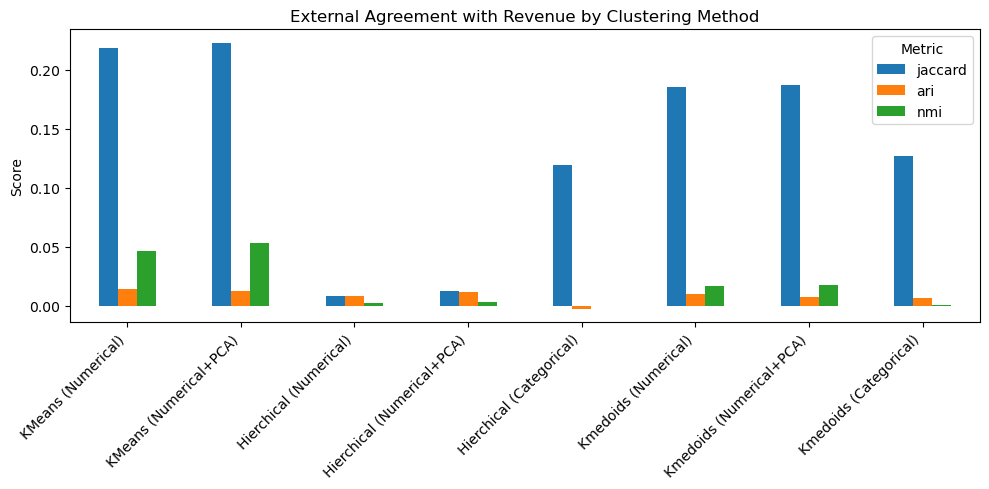

In [87]:
metrics_to_plot = ['jaccard', 'ari', 'nmi']
all_results_df[metrics_to_plot].plot(kind='bar', figsize=(10,5))
plt.title('External Agreement with Revenue by Clustering Method')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

Text(5, 5, 'KMeans (Numerical)')

Text(5, 5, 'KMeans (Numerical+PCA)')

Text(5, 5, 'Hierchical (Numerical)')

Text(5, 5, 'Hierchical (Numerical+PCA)')

...

Text(5, 5, 'Kmedoids (Numerical+PCA)')

Text(5, 5, 'Kmedoids (Categorical)')

Text(0.5, 0, 'Silhouette Score (internal quality)')

Text(0, 0.5, 'Jaccard Index (agreement with Revenue)')

Text(0.5, 1.0, 'Internal Quality vs External Alignment')

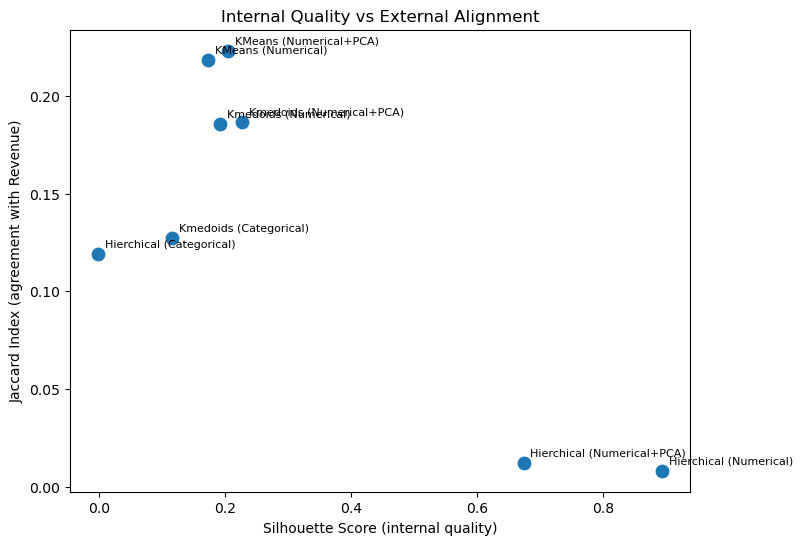

In [88]:
plt.figure(figsize=(8,6))
plt.scatter(all_results_df['silhouette'], all_results_df['jaccard'], s=80)

for method in all_results_df.index:
    plt.annotate(method, (all_results_df.loc[method, 'silhouette'], all_results_df.loc[method, 'jaccard']),
                 fontsize=8, xytext=(5,5), textcoords='offset points')

plt.xlabel('Silhouette Score (internal quality)')
plt.ylabel('Jaccard Index (agreement with Revenue)')
plt.title('Internal Quality vs External Alignment')
plt.show()

We select K-Means (Numerical+PCA) as our best clustering method based on Jaccard Index (0.223)

Among all clustering configurations tested, K-Means (Numerical+PCA) achieves the best alignment with the true 
Revenue labels (Jaccard = 0.223, NMI = 0.053), and is essentially tied for best ARI (0.012). This is despite 
NOT having the highest internal cluster quality — Hierarchical clustering achieves dramatically higher 
silhouette scores (up to 0.894), yet its Jaccard/ARI/NMI are near zero, indicating it identifies a compact, 
well-separated structure in the data that is unrelated to purchasing behavior. Hierarchical's high reported 
accuracy (~0.84) is likewise misleading, reflecting the ~85% majority-class baseline rather than genuine 
predictive skill, since both Jaccard and ARI are close to zero. We therefore select K-Means (Numerical+PCA) as 
our representative clustering-based approach for the final comparison against our best supervised classifier.

## Best classifier vs Best clustering method

We have observed that the best clustering method performs best with numerical features + PCA dimensionality reduction. Let us now see how the best classifier performs with NUM_PCA

### Best classifier with NUM_PCA

In [89]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_data[numerical_cols])

y_train=train_data['Revenue'].astype(int)
y_test=test_data['Revenue'].astype(int)

pca = PCA(n_components=6)
X_train_pca = pca.fit_transform(X_train_scaled)

X_test_scaled = scaler.transform(test_data[numerical_cols])   # note: transform, not fit_transform
X_test_pca = pca.transform(X_test_scaled)                    # note: transform, not fit_transform

lr_pca = LogisticRegression(max_iter=1000, class_weight='balanced')
lr_pca.fit(X_train_pca, y_train)

y_pred_lr_pca = lr_pca.predict(X_test_pca)
y_proba_lr_pca = lr_pca.predict_proba(X_test_pca)[:, 1]

LogisticRegression(class_weight='balanced', max_iter=1000)

In [90]:
best_classifier.fit(X_pca_NUMfinal, y)

Pipeline(steps=[('scaler', StandardScaler()),
                ('lasso',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    solver='liblinear'))])

In [91]:
y_pred_lr = best_classifier.predict(X_test_pca)  # adjust variable names to yours
y_proba_lr = best_classifier.predict_proba(X_test_pca)[:, 1]

lr_results = {
    'Method': 'Logistic Regression (Supervised)',
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr),
    'recall': recall_score(y_test, y_pred_lr),
    'f1': f1_score(y_test, y_pred_lr),
    'roc_auc': roc_auc_score(y_test, y_proba_lr)
}
print(lr_results)
lr_results

len(pred_labels_NUM_PCAmedoids)

{'Method': 'Logistic Regression (Supervised)', 'accuracy': 0.881570408825438, 'precision': 0.5814696485623003, 'recall': 0.7794432548179872, 'f1': 0.6660567246111619, 'roc_auc': np.float64(0.9129564651307521)}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


{'Method': 'Logistic Regression (Supervised)',
 'accuracy': 0.881570408825438,
 'precision': 0.5814696485623003,
 'recall': 0.7794432548179872,
 'f1': 0.6660567246111619,
 'roc_auc': np.float64(0.9129564651307521)}

9248

## Best clustering as predictor

In [92]:
def clusters_to_predictions(cluster_labels, y_true):
    cluster_to_class = {}
    cluster_to_prob = {}
    for c in np.unique(cluster_labels):
        mask = cluster_labels == c
        cluster_to_class[c] = pd.Series(y_true[mask]).mode()[0]
        cluster_to_prob[c] = pd.Series(y_true[mask]).mean()  # proportion of buyers, used as pseudo-probability
    predictions = np.array([cluster_to_class[c] for c in cluster_labels])
    probabilities = np.array([cluster_to_prob[c] for c in cluster_labels])
    return predictions, probabilities, cluster_to_class

# pred_labels_NUM_PCA_medoids = your K-Medoids cluster assignments on training data (NUM + PCA)
y_pred_kmeans, y_proba_kmeans, mapping = clusters_to_predictions(pred_labels_NUM_PCA_kmeans, y)
print("Cluster -> class mapping:", mapping)

Cluster -> class mapping: {np.int32(0): np.int64(0), np.int32(1): np.int64(0)}


In [93]:
test_clusters_km = kmeans_NUM_PCA.predict(X_test_pca)  # assign test points to existing clusters

y_pred_kmeans_test = np.array([mapping[c] for c in test_clusters_km])

# For probabilities, build the buyer-proportion dict from training too
cluster_probs = {}
for c in np.unique(pred_labels_NUM_PCA_kmeans):
    mask = pred_labels_NUM_PCA_kmeans == c
    cluster_probs[c] = pd.Series(y)[mask].mean()

y_proba_kmeans_test = np.array([cluster_probs[c] for c in test_clusters_km])

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [94]:
kmeans_results = {
    'Method': 'K-Means (NUM + PCA) as Classifier',
    'accuracy': accuracy_score(y_test, y_pred_kmeans_test),
    'precision': precision_score(y_test, y_pred_kmeans_test),
    'recall': recall_score(y_test, y_pred_kmeans_test),
    'f1': f1_score(y_test, y_pred_kmeans_test),
    'roc_auc': roc_auc_score(y_test, y_pred_kmeans_test)
}

kmeans_results

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


{'Method': 'K-Means (NUM + PCA) as Classifier',
 'accuracy': 0.8484750162232316,
 'precision': 0.0,
 'recall': 0.0,
 'f1': 0.0,
 'roc_auc': np.float64(0.5)}

Text(0.5, 1.0, 'K-Means Clusters (PC1 vs PC2)')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

Text(0.5, 1.0, 'True Revenue Labels (PC1 vs PC2)')

Text(0.5, 0, 'PC1')

Text(0, 0.5, 'PC2')

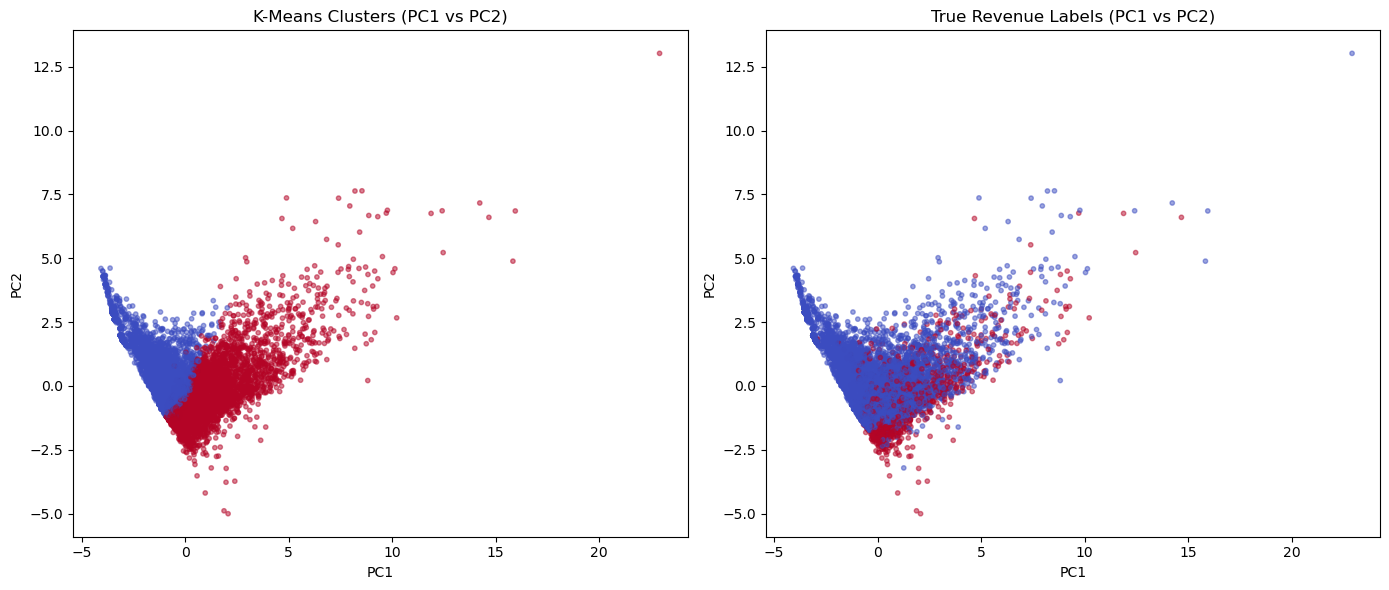

In [95]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: colored by predicted cluster
axes[0].scatter(X_NUMpca_array[:,0], X_NUMpca_array[:,1], c=pred_labels_NUM_PCA_kmeans, cmap='coolwarm', alpha=0.5, s=10)
axes[0].set_title('K-Means Clusters (PC1 vs PC2)')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

# Right: colored by TRUE Revenue label
axes[1].scatter(X_NUMpca_array[:,0], X_NUMpca_array[:,1], c=y, cmap='coolwarm', alpha=0.5, s=10)
axes[1].set_title('True Revenue Labels (PC1 vs PC2)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout()
plt.show()

In [96]:
pd.DataFrame([lr_results, kmeans_results]).set_index('Method')

,accuracy,precision,recall,f1,roc_auc
Method,,,,,
Logistic Regression (Supervised),0.881570,0.58147,0.779443,0.666057,0.912956
K-Means (NUM + PCA) as Classifier,0.848475,0.00000,0.000000,0.000000,0.500000


<Figure size 700x600 with 0 Axes>

Text(0.5, 0, 'False Positive Rate')

Text(0, 0.5, 'True Positive Rate')

Text(0.5, 1.0, 'ROC Curve: Best Classifier vs Best Clustering Method')

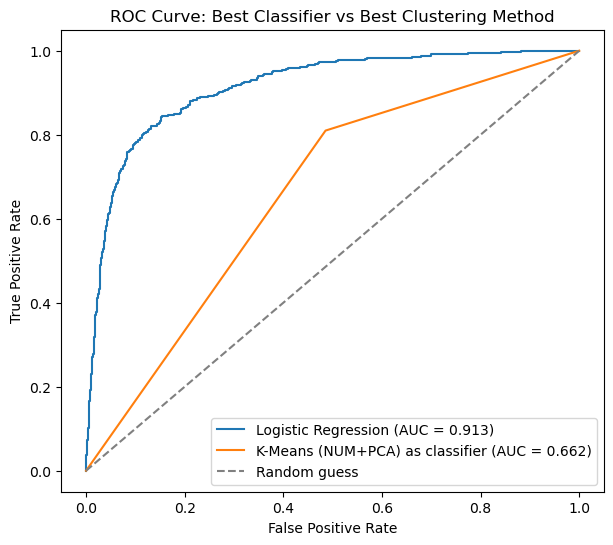

In [97]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Logistic Regression — evaluated on the test set
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = auc(fpr_lr, tpr_lr)

# K-Means (NUM+PCA) as classifier — make sure y_proba_kmeans_test comes from TEST-set cluster assignments
fpr_km, tpr_km, _ = roc_curve(y, y_proba_kmeans)
auc_km = auc(fpr_km, tpr_km)

plt.figure(figsize=(7,6))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.3f})', color='tab:blue')
plt.plot(fpr_km, tpr_km, label=f'K-Means (NUM+PCA) as classifier (AUC = {auc_km:.3f})', color='tab:orange')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Best Classifier vs Best Clustering Method')
plt.legend()
plt.show()

f1 score = 0 means that this model never predicted the positive class but high accuracy means that the model predicted all of the negative classes. This is due to the imbalance between the two classes (Revenue true and false). 

---
---
---

# CONCLUSION

---
---
---